# FSTT-Net — final run notebook (A100)

**Frequency-Spatial Temporal Semantic Token Transformer for Deepfake Detection**

Cell 1 is a 10-second environment check. Cell 2 is the whole study: seven stages, fully
resumable. If the session drops, run cell 2 again and it continues.

---

## Runtime

**Runtime → Change runtime type → A100 GPU, High-RAM on.** Never a TPU — this code is
CUDA-native and a TPU would silently drop it to CPU.

Batch size auto-tunes: A100 → 40, H100 → 64, L4 → 24, T4 → 16. On out-of-memory the
cell halves the batch and retries.

| GPU | Total |
|---|---|
| A100 40 GB | **~6–7 h** |
| H100 80 GB | ~4–5 h |
| L4 24 GB | ~9–11 h |
| T4 16 GB | ~14–16 h |

## Three things fixed in this version

1. **The numpy crash.** Every `pip install` inside the cell now uses `--no-deps`, so it
   can never pull a different numpy (or torch) into a live session. That was the cause
   of `cannot import name '_center' from numpy._core.umath`. If an install does move
   numpy anyway, the cell stops immediately and tells you to restart, instead of dying
   forty lines later inside scipy.
2. **The wrong-root crash.** `AUTO_FIND_ROOT` searches Drive for a real face cache when
   `DRIVE_ROOT` has none, so a typo like `fsttnet_v3` for `fsttnet_v2` no longer stops
   the run — it prints what it found and uses it.
3. **Your Celeb-DF training is not repeated.** The cell adopts the older
   `checkpoints/last2_v6/{NAME}_best.safetensors` files as the Celeb-DF seed-42 runs,
   after verifying they load into the current architecture. That saves about 2.5 hours.
   If the architecture does not match it says so and retrains rather than loading
   something wrong.

## What comes out, against the base paper

| Base paper (Peng et al., TIFS 2025) | This notebook |
|---|---|
| Table I — semantic coefficient α | **Table I**, same sweep, measured here |
| Table II/III — intra-dataset ACC/AUC | **Table II**, three corpora, one schedule |
| Table IV/V — cross-dataset AUC | **Table IV**, the full train→test matrix |
| Table VI/VII — ablation | **Table VII**, cumulative A→E |
| Table VIII — iterations, FLOPs, params | **Table VIII** + **Table XI** with latency |
| Fig. 3 — token clusters per iteration | **Fig. 3**, same visualisation |
| *(absent)* | **Table XII** mean ± std over 3 seeds |
| *(absent)* | **Table XIII** paired bootstrap CI + McNemar |
| *(absent)* | ROC / PR / DET |
| *(absent)* | **Table X** robustness under JPEG, blur, noise, downscale |

The last four rows are the honest answer to "better than the base paper" — not larger
numbers, since they report 100.00 AUC on Celeb-DF, but evidence they never provide.

## Before you start

Run cell 1. It prints the root where your face caches actually live — put that in
`DRIVE_ROOT` at the top of cell 2. Do **not** change `EMBED_DIMS`, `STEM_MODEL` or
`STEM_INDEX`: the Celeb-DF checkpoints load against those exact values.

In [ ]:
!pip install -q --force-reinstall --no-cache-dir numpy==2.0.2
!pip install -q --no-deps "opencv-python-headless<5"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 206.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 MB 49.5 MB/s eta 0:00:00


In [ ]:
# ############################################################################
# CELL 1 (optional) :: environment sanity check - run this FIRST, once
# ----------------------------------------------------------------------------
# Two things have gone wrong in previous sessions and both are avoidable:
#   * a pip install pulled a different numpy into a live session, after which
#     the interpreter fails with "cannot import name _center from numpy._core.umath"
#   * a dropped Drive mount left a plain local folder at /content/drive, so the
#     data looked missing when it was actually fine
# This cell checks both in a few seconds. If it prints ALL GOOD, run cell 2.
# ############################################################################
import os, sys, subprocess
from pathlib import Path

problems = []

# ---- Drive: ismount(), not is_dir() ---------------------------------------
DRIVE = Path("/content/drive/NIT-PATNA-P2")
try:
    from google.colab import drive
    import shutil
    if not os.path.ismount(DRIVE):
        if DRIVE.exists() and any(DRIVE.iterdir()):
            stale = Path("/content/drive_stale")
            if stale.exists():
                shutil.rmtree(stale)
            DRIVE.rename(stale)
            print("stale local /content/drive moved to", stale)
        drive.mount(str(DRIVE))
    print("Drive mounted :", os.path.ismount(DRIVE))
except Exception as e:
    print("Drive          :", e)

# ---- numpy self-consistency ------------------------------------------------
try:
    import numpy as np
    import numpy.testing, numpy._core.strings
    import torch
    _ = torch.from_numpy(np.zeros(4, dtype=np.float32)).numpy().sum()
    print(f"numpy         : {np.__version__}  OK")
    print(f"torch         : {torch.__version__}  cuda={torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"gpu           : {torch.cuda.get_device_name(0)} "
              f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.0f} GB")
    else:
        problems.append("no GPU - Runtime > Change runtime type > A100 GPU (never a TPU)")
except Exception as e:
    problems.append(f"numpy/torch broken: {e}")
    print("numpy/torch   : BROKEN ->", e)

try:
    import cv2
    print(f"opencv        : {cv2.__version__}")
    if int(cv2.__version__.split('.')[0]) >= 5:
        problems.append("OpenCV 5.x loaded - cell 2 will ask for one restart, that is expected")
except Exception as e:
    print("opencv        : not importable ->", e)

try:
    import timm
    print(f"timm          : {timm.__version__}")
except Exception as e:
    problems.append(f"timm missing: {e}")

# ---- where the data actually is -------------------------------------------
print("\nface caches found on Drive:")
found = 0
try:
    for m in Path("/content/drive/MyDrive/NIT-PATNA-P2").glob("**/faces/*/manifest.csv"):
        import pandas as pd
        try:
            df = pd.read_csv(m)
            alive = df.face.head(20).map(lambda p: Path(str(p)).exists()).sum()
            root = m.parent.parent.parent
            print(f"  {m.parent.name:<14} {len(df):>8,} crops  "
                  f"{alive}/20 resolve   root={root}")
            found += 1
        except Exception:
            pass
except Exception as e:
    print("  search failed:", e)
if found == 0:
    problems.append("no face cache found - cell 2 stage 0 will have to build it")

print("\n" + "=" * 78)
if problems:
    print("ISSUES TO SORT OUT FIRST")
    print("=" * 78)
    for i, p in enumerate(problems, 1):
        print(f"  {i}. {p}")
    print("\nIf numpy is broken:")
    print("    !pip install -q --force-reinstall --no-cache-dir numpy==2.0.2")
    print("  then Runtime > Restart session and run this cell again.")
else:
    print("ALL GOOD - set DRIVE_ROOT in cell 2 to the root printed above, then run it.")
print("=" * 78)


Drive          : Mountpoint must be in a directory that exists
numpy         : 2.0.2  OK
torch         : 2.11.0+cu128  cuda=True
gpu           : NVIDIA RTX PRO 6000 Blackwell Server Edition 95 GB
opencv        : 4.14.0
timm          : 1.0.28

face caches found on Drive:

ISSUES TO SORT OUT FIRST
  1. no face cache found - cell 2 stage 0 will have to build it

If numpy is broken:
    !pip install -q --force-reinstall --no-cache-dir numpy==2.0.2
  then Runtime > Restart session and run this cell again.


---
## Cell 2 — the whole study

Seven stages, resumable. Run it, and rerun it whenever the session drops or the closing
block prints **NOT FINISHED**.

Mounted at /content/drive
Drive mounted: True
FSTT-Net MASTER CELL
root    : /content/drive/MyDrive/NIT-PATNA-P2/fsttnet_v2
device  : cuda | NVIDIA RTX PRO 6000 Blackwell Server Edition 95 GB
batch   : 64 (auto-tuned for NVIDIA RTX PRO 6000 Blackwell Server Edition, 95 GB)
budget  : 13.0 h | stages [0, 1, 2, 3, 4, 5, 6]
corpora : ['celebdf', 'ff++', 'wilddeepfake'] | primary celebdf

--------------------------------------------------------------------------------------------
STAGE 0 :: DATA
--------------------------------------------------------------------------------------------
  celebdf        121,175 crops | sequences=6,529 | splits=['test', 'train', 'val']
  ff++           38,613 crops | sequences=3,000 | splits=['test', 'train', 'val']

  WildDeepfake missing - re-extracting (capped, verified)


100%|██████████| 10.1G/10.1G [01:44<00:00, 104MB/s] 

Extracting files...


  downloaded maysuni/wild-deepfake
  indexed 189,713 images | sequences=1,716
  capped at 20/sequence -> 34,192 images
  splits: {'train': 24356, 'test': 6579, 'val': 3257}


faces[wilddeepfake]:   0%|          | 0/34192 [00:00<?, ?it/s]

...

,Corpus,Comparison,dAUC (pp),95% CI,Bootstrap p,McNemar p,Videos,Significant
0,celebdf,FSTT-Net vs STT-Repro,0.005,"[-0.04, 0.05]",0.830,0.7237,518,no
1,ff++,FSTT-Net vs STT-Repro,0.296,"[0.09, 0.56]",0.002,0.1456,599,yes
2,wilddeepfake,FSTT-Net vs STT-Repro,1.652,"[0.36, 2.99]",0.011,0.8501,331,yes



--------------------------------------------------------------------------------------------
STAGE 6 :: EFFICIENCY, FIGURES, EXPORT
--------------------------------------------------------------------------------------------



TABLE XI - efficiency


,Method,Params (M),GFLOPs/clip,Latency (ms/clip),Throughput (clips/s)
0,STT-Repro,21.55,NaN,6.89,145.1
1,FSTT-Net,23.84,NaN,7.84,127.6
2,Swin-T,27.52,NaN,2.65,377.1
3,EfficientNet-B4,17.55,NaN,3.88,257.5
4,F3Net-Lite,4.01,NaN,1.99,503.6



[FIG 8] fig_training


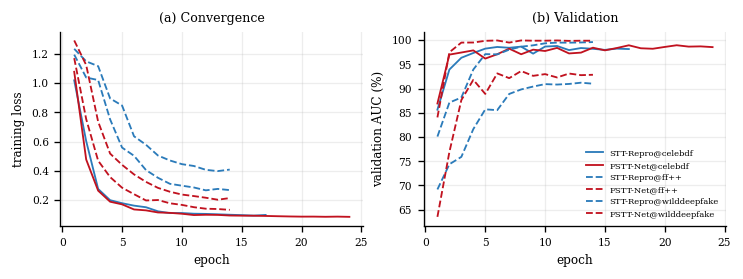


[FIG 9] fig_roc_pr_det


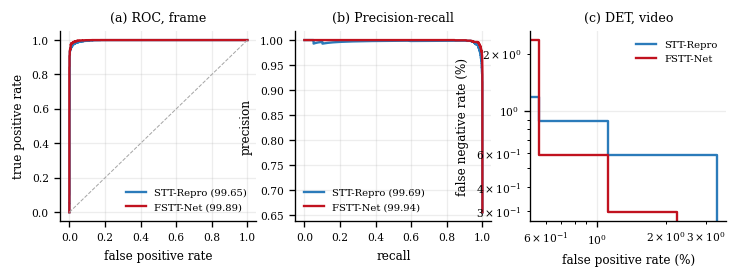


[FIG 17] fig_cross_dataset


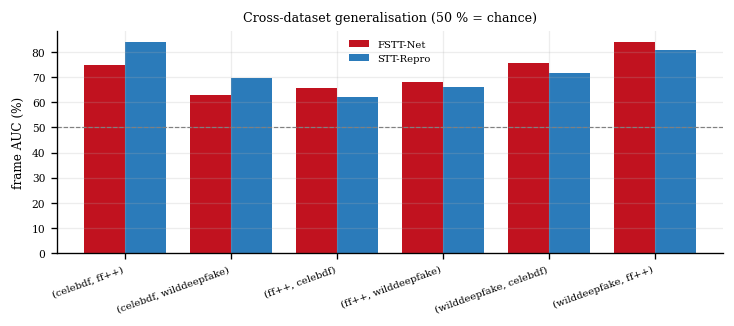


[FIG 20] fig_robustness


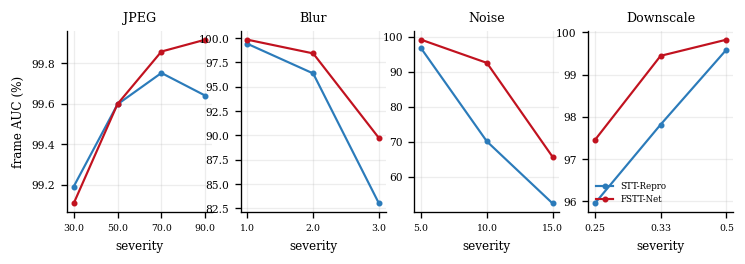


[FIG 20(b)] fig_robustness_delta


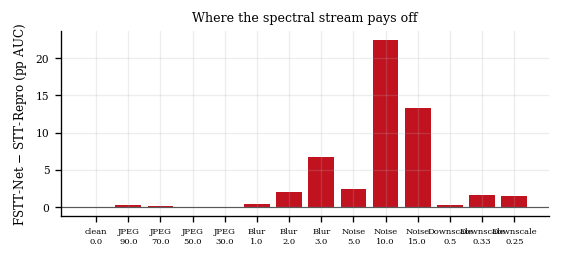


[FIG 3] fig_token_clusters


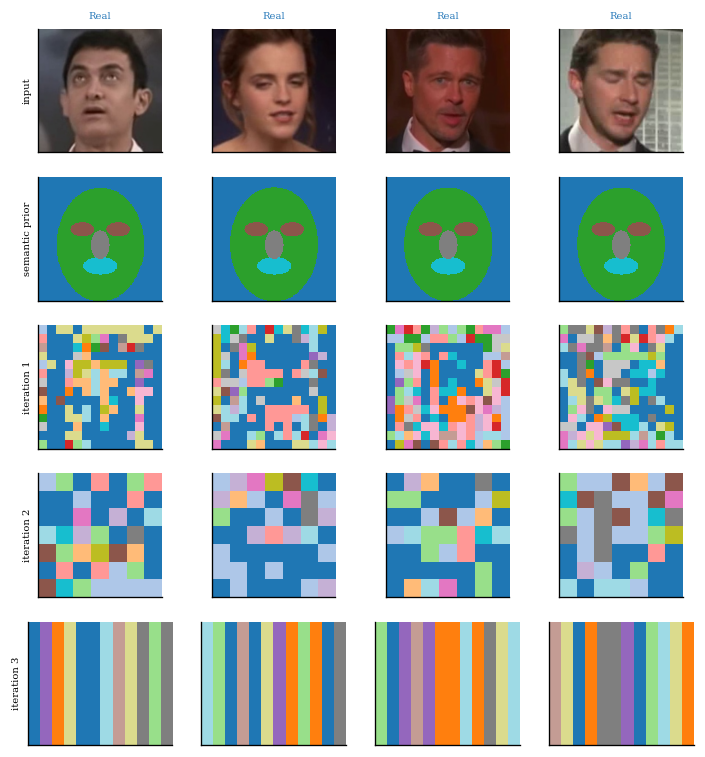


[FIG 12] fig_seed_variance


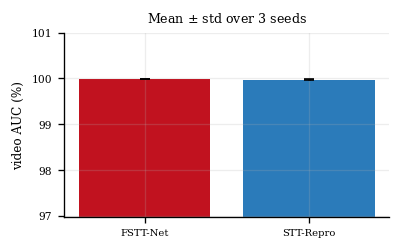


bundle -> /content/drive/MyDrive/NIT-PATNA-P2/fsttnet_v2/manuscript_pack/FSTTNet_paper_assets.zip (4.4 MB)

RUN COMPLETE  (elapsed 13.76 h)
assets -> /content/drive/MyDrive/NIT-PATNA-P2/fsttnet_v2/manuscript_pack

--------------------------------------------------------------------------------------------
WHAT THE NUMBERS SUPPORT
--------------------------------------------------------------------------------------------
  seeds: FSTT-Net 99.98 +/- 0.00 vs STT-Repro 99.97 +/- 0.01
  -> the gap is larger than the combined spread; it survives seed noise
  celebdf: dAUC +0.005 pp, CI [-0.04, 0.05] -> NOT distinguishable from run-to-run variation
  ff++: dAUC +0.296 pp, CI [0.09, 0.56] -> a real, attributable improvement
  wilddeepfake: dAUC +1.652 pp, CI [0.36, 2.99] -> a real, attributable improvement

  Where the interval clears zero you may state the improvement plainly.
  Where it does not, report the number and do not call it an improvement.


In [ ]:
# ############################################################################
# FSTT-Net :: MASTER CELL - the whole study in one cell
# ============================================================================
# Colab Pro+ (A100/L4, 40-51 GB RAM). Budget 12-14 h. Fully RESUMABLE:
# if the session dies, rerun this same cell and it continues where it stopped.
#
# STAGES (each one skips itself if its output is already on Drive)
#   0  environment, Drive, data check, WildDeepfake re-extraction if needed
#   1  train STT-Repro and FSTT-Net on every corpus in TRAIN_CORPORA
#   2  intra-dataset test evaluation  -> Table II / III
#   3  cross-dataset matrix, every train->test pair -> Table IV / V
#   4  robustness under JPEG / blur / noise / downscale -> Table X
#   5  paired significance, bootstrap CI + McNemar -> Table XIII
#   6  efficiency, all tables, all figures, LaTeX, zip -> manuscript_pack/
#
# WHY WildDeepfake VANISHED LAST TIME, and what changed
# 189,713 tiny files went to Drive in one session; Drive throttles file
# creation and never flushed them. Stage 0 now caps images per sequence
# (MAX_IMAGES_PER_SEQ), VERIFIES on disk before writing the manifest, and
# refuses to mark the corpus done if more than 5% failed to land.
# ############################################################################

# ---------------------------------------------------------------------------
# 0. SETTINGS - the only block you normally touch
# ---------------------------------------------------------------------------
DRIVE_ROOT   = "/content/drive/MyDrive/NIT-PATNA-P2/fsttnet_v2"
AUTO_FIND_ROOT = True             # if DRIVE_ROOT has no face cache, search Drive
TIME_BUDGET_HOURS = 13.0          # clean stop before Colab kills the session
RUN_STAGES   = [0, 1, 2, 3, 4, 5, 6]

TRAIN_CORPORA = ["celebdf", "ff++", "wilddeepfake"]   # one model pair per corpus
PRIMARY       = "celebdf"                              # headline corpus
MODEL_NAMES   = ["STT-Repro", "FSTT-Net"]

# stage 0 - WildDeepfake repair
MAX_IMAGES_PER_SEQ = 20           # 1,716 seqs x 20 ~= 34k files, Drive-safe
REEXTRACT_WDF      = True         # skipped automatically if its manifest is valid

# architecture (must stay identical across runs or checkpoints will not load)
EMBED_DIMS    = (128, 256, 512)
NUM_HEADS     = (2, 4, 8)
DEPTHS        = (2, 2, 2)
STEM_MODEL    = "efficientnet_b3"
STEM_INDEX    = 3                 # stride 16 -> 14x14 = 196 tokens at 224 px
FINETUNE_STEM = True
STEM_LR_MULT  = 0.10

# optimisation - tuned for an A100 (40 GB). AUTO_TUNE_BATCH rescales for
# whatever GPU you actually get, so T4 / L4 / H100 all work unchanged.
EPOCHS        = {"celebdf": 24, "ff++": 14, "wilddeepfake": 14}
BATCH_SIZE    = 40                # A100 default; auto-scaled below
AUTO_TUNE_BATCH = True            # set False to force BATCH_SIZE exactly
TRUNK_LR, WD  = 3.0e-4, 0.02
EARLY_STOP    = 6
TOPK_AVG      = 3
W_CE, W_FOCAL, W_CENTER, W_CONSIST, W_DIVERSE = 1.0, 0.0, 0.02, 0.05, 0.0

# the one architectural knob worth trying if the spectral stream looks inert:
# it blanks one input stream at random so the network cannot ignore the other.
MODALITY_DROPOUT = 0.0            # try 0.15 if FSTT-Net does not beat STT-Repro

# --- what raises this from "a result" to a Transactions-grade evidence base ---
RUN_BASELINES = True              # Swin-T etc. under the SAME schedule, on PRIMARY
# ViT-B/16 (85.8 M, slowest, weakest at 0.8567) and Xception (its pretrained
# weights failed to load last time) are dropped by default. Add them back if a
# reviewer asks - the code supports all five.
BASELINE_NAMES = ["Swin-T", "EfficientNet-B4", "F3Net-Lite"]
BASELINE_EPOCHS = 10

RUN_SEEDS = True                  # mean +/- std for the two token models on PRIMARY
SEEDS = [42, 1337, 2024]

RUN_ABLATION = True               # cumulative component study, base paper Table VI/VII
ABLATION_EPOCHS = 8

RUN_SWEEPS = True                 # base paper Table I (alpha) and Table VIII (iterations)
ALPHA_SWEEP = [0.1, 0.2, 0.4, 0.8]
ITER_SWEEP = [1, 2, 3]
SWEEP_EPOCHS = 6

# Ablation and sweep runs measure RELATIVE differences, so they do not need the
# full training set every epoch. Headline runs (Tables II, XII, XIII) always use
# everything - only tagged runs are capped.
MAX_TRAIN_CLIPS       = None      # headline runs: full training set
MAX_TRAIN_CLIPS_SWEEP = 12000     # ablation + sweeps only

RUN_INTERPRET = True              # token-cluster maps, the base paper's Fig. 3

# evaluation caps (keep runtime sane; None = use everything)
MAX_CLIPS_EVAL   = 6000
MAX_CLIPS_CROSS  = 4000
MAX_CLIPS_ROBUST = 1500
BOOTSTRAP_N      = 2000

SEED = 42

# ===========================================================================
import sys, os, subprocess, shutil, importlib


def _pip(*a):
    """Always installed with --no-deps: a plain `pip install` here would pull a
    different numpy (or torch) into a session that already has one loaded, and
    the running interpreter then fails with things like
    'cannot import name _center from numpy._core.umath'."""
    subprocess.run([sys.executable, "-m", "pip", *a, "--no-deps"], check=False,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)


def _numpy_healthy():
    try:
        import numpy, numpy.testing, numpy._core.strings   # the module that breaks
        return True
    except Exception:
        return False


_NP_WAS_OK = _numpy_healthy()


def _cv_major():
    try:
        from importlib.metadata import version
    except Exception:
        return None
    for p in ("opencv-python-headless", "opencv-python",
              "opencv-contrib-python-headless", "opencv-contrib-python"):
        try:
            return int(version(p).split(".")[0])
        except Exception:
            continue
    return None


if (_cv_major() or 99) >= 5:
    print("pinning OpenCV to 4.x (5.x dropped readNetFromCaffe) ...")
    _pip("install", "-q", "--force-reinstall", "opencv-python-headless<5")
    if _NP_WAS_OK and not _numpy_healthy():
        print("=" * 92)
        print("THE OpenCV INSTALL JUST MOVED numpy UNDER A LIVE SESSION")
        print("=" * 92)
        print("Nothing is broken on disk. RESTART THE RUNTIME and run this cell")
        print("again - the install is already done, so it will go straight through.")
        print("=" * 92)
        raise SystemExit("restart required")

_live_cv = sys.modules.get("cv2")
if _live_cv is not None and int(getattr(_live_cv, "__version__", "0").split(".")[0]) >= 5:
    print("=" * 92)
    print("RESTART THE RUNTIME, THEN RUN THIS CELL AGAIN")
    print("OpenCV 4.x is installed but a 5.x build is already loaded.")
    print("=" * 92)
    raise SystemExit("restart required")

for _m, _p in {"kagglehub": "kagglehub", "safetensors": "safetensors",
               "timm": "timm", "pandas": "pandas", "tqdm": "tqdm"}.items():
    try:
        importlib.import_module(_m)
    except Exception:
        print(f"installing {_p} ...")
        _pip("install", "-q", _p)
        if _NP_WAS_OK and not _numpy_healthy():
            print("=" * 92)
            print(f"INSTALLING {_p} MOVED numpy UNDER A LIVE SESSION")
            print("RESTART THE RUNTIME and run this cell again.")
            print("=" * 92)
            raise SystemExit("restart required")

from pathlib import Path

# ---- Drive: ismount(), NOT is_dir() ---------------------------------------
_DRIVE = Path("/content/drive")
try:
    from google.colab import drive as _gd
    if not os.path.ismount(_DRIVE):
        if _DRIVE.exists() and any(_DRIVE.iterdir()):
            _s = Path("/content/drive_stale")
            if _s.exists():
                shutil.rmtree(_s)
            _DRIVE.rename(_s)
            print("stale local /content/drive moved to", _s)
        _gd.mount(str(_DRIVE))
    print("Drive mounted:", os.path.ismount(_DRIVE))
except Exception as _e:
    print("Drive unavailable (fine if DRIVE_ROOT is local):", _e)

import json, math, time, random, warnings, hashlib, threading, urllib.request, copy, gc, zipfile
from collections import defaultdict, OrderedDict
from dataclasses import dataclass
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy import stats
from scipy.fftpack import dct
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, det_curve, confusion_matrix,
                             accuracy_score, f1_score, balanced_accuracy_score,
                             brier_score_loss)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x.to_string() if hasattr(x, "to_string") else x)

try:
    import numpy.testing
    _ = torch.from_numpy(np.zeros(4, dtype=np.float32)).numpy().sum()
except Exception as _e:
    print("=" * 92)
    print("NUMPY INSTALL IS BROKEN:", _e)
    print("    !pip install -q --force-reinstall --no-cache-dir numpy==2.0.2")
    print("then RESTART the runtime and rerun this cell.")
    print("=" * 92)
    raise

T0 = time.time()
def elapsed_h(): return (time.time() - T0) / 3600.0
def left_h():    return TIME_BUDGET_HOURS - elapsed_h()

ROOT = Path(DRIVE_ROOT)
if AUTO_FIND_ROOT and not list((ROOT / "faces").glob("*/manifest.csv")):
    print(f"no face cache under {ROOT} - searching Drive ...")
    cands = []
    try:
        for m in Path("/content/drive/MyDrive").glob("**/faces/*/manifest.csv"):
            cands.append(m.parent.parent.parent)
    except Exception as _e:
        print("  search failed:", _e)
    if cands:
        best = max(set(cands), key=cands.count)
        n = len(list((best / "faces").glob("*/manifest.csv")))
        print(f"  found {n} manifest(s) under {best} - using that as ROOT")
        ROOT = best
    else:
        print("  nothing found; run the data stage or fix DRIVE_ROOT by hand")
FACE_DIR  = ROOT / "faces"
MODEL_DIR = ROOT / "models"
CKPT_DIR  = ROOT / "checkpoints" / "master"
EXP_DIR   = ROOT / "experiments"
PACK      = ROOT / "manuscript_pack"
PFIG, PTAB, PRES = PACK / "figures", PACK / "tables", PACK / "results"
for _d in (ROOT, FACE_DIR, MODEL_DIR, CKPT_DIR, EXP_DIR, PACK, PFIG, PTAB, PRES):
    _d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE, CLIP_LEN, N_REGIONS = 224, 4, 5
WORKERS = min(8, max(2, (os.cpu_count() or 4)))

print("=" * 92)
print("FSTT-Net MASTER CELL")
print("=" * 92)
print(f"root    : {ROOT}")
print(f"device  : {DEVICE}"
      + (f" | {torch.cuda.get_device_name(0)} "
         f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.0f} GB"
         if torch.cuda.is_available() else ""))
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
GPU_GB = (torch.cuda.get_device_properties(0).total_memory / 1024**3
          if torch.cuda.is_available() else 0)
if AUTO_TUNE_BATCH and torch.cuda.is_available():
    # keep roughly the same activation footprint on any card
    if GPU_GB >= 70:      BATCH_SIZE = 64      # H100 80 GB
    elif GPU_GB >= 38:    BATCH_SIZE = 40      # A100 40 GB
    elif GPU_GB >= 20:    BATCH_SIZE = 24      # L4 24 GB
    else:                 BATCH_SIZE = 16      # T4 16 GB
    print(f"batch   : {BATCH_SIZE} (auto-tuned for {GPU_NAME}, {GPU_GB:.0f} GB)")
elif not torch.cuda.is_available():
    print("=" * 92)
    print("NO GPU DETECTED")
    print("=" * 92)
    print("Runtime -> Change runtime type -> A100 GPU (or L4 / H100), High-RAM on.")
    print("Do NOT pick a TPU: this code is CUDA-native (torch.autocast('cuda'),")
    print("GradScaler('cuda')) and would silently fall back to CPU, turning a")
    print("6-hour run into several days.")
    print("=" * 92)
print(f"budget  : {TIME_BUDGET_HOURS} h | stages {RUN_STAGES}")
print(f"corpora : {TRAIN_CORPORA} | primary {PRIMARY}")

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.benchmark = True

set_seed()
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True      # big win on A100/H100
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass


# ###########################################################################
# STAGE 0 :: DATA
# ###########################################################################
def load_frames():
    out = {}
    for mp in sorted(FACE_DIR.glob("*/manifest.csv")):
        key = mp.parent.name
        try:
            df = pd.read_csv(mp)
        except Exception:
            continue
        if len(df) == 0 or "face" not in df.columns:
            continue
        if not df.face.head(50).map(lambda p: Path(str(p)).exists()).any():
            print(f"  {key:<14} manifest lists {len(df):,} crops but they are gone")
            continue
        out[key] = df
    return out


DNN_FILES = {
    "deploy.prototxt":
        "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/dnn/"
        "face_detector/deploy.prototxt",
    "res10_300x300_ssd_iter_140000.caffemodel":
        "https://raw.githubusercontent.com/opencv/opencv_3rdparty/"
        "dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
}
_TL = threading.local()
DET = {"calls": 0, "hits": 0}
_DLOCK = threading.Lock()


def _det_net():
    n = getattr(_TL, "net", None)
    if n is None:
        for k, u in DNN_FILES.items():
            p = MODEL_DIR / k
            if not p.exists() or p.stat().st_size < 10_000:
                urllib.request.urlretrieve(u, str(p))
        n = cv2.dnn.readNetFromCaffe(
            str(MODEL_DIR / "deploy.prototxt"),
            str(MODEL_DIR / "res10_300x300_ssd_iter_140000.caffemodel"))
        _TL.net = n
    return n


def crop_face(rgb, margin=0.30, conf=0.60):
    H, W = rgb.shape[:2]
    blob = cv2.dnn.blobFromImage(
        cv2.resize(cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR), (300, 300)),
        1.0, (300, 300), (104.0, 177.0, 123.0))
    net = _det_net(); net.setInput(blob); det = net.forward()
    best, bc = None, 0.0
    for i in range(det.shape[2]):
        c = float(det[0, 0, i, 2])
        if c < conf or c <= bc:
            continue
        x1, y1, x2, y2 = det[0, 0, i, 3:7] * np.array([W, H, W, H])
        if x2 - x1 < 20 or y2 - y1 < 20:
            continue
        best, bc = [x1, y1, x2, y2], c
    with _DLOCK:
        DET["calls"] += 1
        DET["hits"] += best is not None
    if best is None:
        s = min(H, W)
        best = [(W - s) / 2, (H - s) / 2, (W + s) / 2, (H + s) / 2]
    x1, y1, x2, y2 = best
    w, h = x2 - x1, y2 - y1
    cx, cy = x1 + w / 2, y1 + h / 2
    s = max(w, h) * (1 + margin)
    a, b = int(max(0, cx - s / 2)), int(max(0, cy - s / 2))
    c_, d = int(min(W, cx + s / 2)), int(min(H, cy + s / 2))
    crop = rgb[b:d, a:c_]
    if crop.size == 0:
        crop = rgb
    return cv2.resize(crop, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)


def extract_wilddeepfake():
    out = FACE_DIR / "wilddeepfake"
    out.mkdir(parents=True, exist_ok=True)
    import kagglehub
    src = None
    for slug in ["maysuni/wild-deepfake", "doosexe/voxear-faces-wilddeepfake"]:
        try:
            src = kagglehub.dataset_download(slug)
            print(f"  downloaded {slug}")
            break
        except Exception as e:
            print(f"  {slug} -> {e}")
    if src is None:
        print("  could not download WildDeepfake - skipping")
        return None

    IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    rows = []
    for dp, _, fns in os.walk(src):
        for fn in fns:
            if Path(fn).suffix.lower() not in IMG_EXT:
                continue
            full = Path(dp) / fn
            rel = str(full.relative_to(src))
            s = rel.lower().replace("\\", "/")
            fk = any(k in s for k in ["fake", "deepfake", "manipulated", "/1/"])
            rk = any(k in s for k in ["real", "original", "/0/"])
            lab = 1 if (fk and not rk) else (0 if (rk and not fk) else None)
            if lab is None:
                continue
            stem = Path(rel).stem
            trimmed = stem.rstrip("0123456789").rstrip("_-") or stem
            rows.append({"path": str(full), "rel": rel, "label": lab,
                         "video_id": f"wilddeepfake/{Path(rel).parent / trimmed}",
                         "identity": trimmed})
    idx = pd.DataFrame(rows)
    if len(idx) == 0:
        print("  no labelled images found")
        return None
    print(f"  indexed {len(idx):,} images | sequences={idx.video_id.nunique():,}")

    idx = (idx.sort_values("rel").groupby("video_id", group_keys=False)
              .head(MAX_IMAGES_PER_SEQ).reset_index(drop=True))
    print(f"  capped at {MAX_IMAGES_PER_SEQ}/sequence -> {len(idx):,} images")

    grp = idx.identity.fillna(idx.video_id)
    u = sorted(grp.unique()); rng = np.random.RandomState(SEED); rng.shuffle(u)
    idx["split"] = np.where(grp.isin(set(u[:max(1, int(0.20 * len(u)))])), "test", "train")
    tr = idx[idx.split == "train"]
    g2 = tr.identity.fillna(tr.video_id)
    u2 = sorted(g2.unique()); rng2 = np.random.RandomState(SEED + 1); rng2.shuffle(u2)
    idx.loc[idx.split == "train", "split"] = np.where(
        g2.isin(set(u2[:max(1, int(0.12 * len(u2)))])), "val", "train")
    print("  splits:", idx.split.value_counts().to_dict())

    def one(r):
        try:
            sub = out / r.split / str(r.label)
            sub.mkdir(parents=True, exist_ok=True)
            op = sub / f"{hashlib.md5(r.rel.encode()).hexdigest()[:12]}_00000.jpg"
            if not op.exists():
                im = cv2.imread(r.path)
                if im is None:
                    return None
                face = crop_face(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
                cv2.imwrite(str(op), cv2.cvtColor(face, cv2.COLOR_RGB2BGR),
                            [int(cv2.IMWRITE_JPEG_QUALITY), 95])
            return {"dataset": "wilddeepfake", "face": str(op), "label": r.label,
                    "video_id": r.video_id, "split": r.split, "frame": 0,
                    "identity": r.identity, "src": r.path}
        except Exception:
            return None

    DET["calls"] = DET["hits"] = 0
    recs = []
    with ThreadPoolExecutor(max_workers=min(8, WORKERS)) as ex:
        futs = [ex.submit(one, r) for r in idx.itertuples()]
        for fu in tqdm(as_completed(futs), total=len(futs), desc="faces[wilddeepfake]"):
            r = fu.result()
            if r:
                recs.append(r)
    print(f"  detection rate {DET['hits']/max(DET['calls'],1):.1%}")

    df = pd.DataFrame(recs)
    print("  verifying the files actually landed on Drive ...")
    time.sleep(20)
    alive = df.face.map(lambda p: Path(p).exists())
    print(f"  {int(alive.sum()):,} / {len(df):,} crops present")
    if alive.mean() < 0.95:
        print("  MORE THAN 5% DID NOT FLUSH - manifest not written.")
        print("  Lower MAX_IMAGES_PER_SEQ to 10 and rerun this cell.")
        return None
    df = df[alive].reset_index(drop=True)
    df.to_csv(out / "manifest.csv", index=False)
    print(f"  manifest written: {len(df):,} crops | "
          f"sequences={df.video_id.nunique():,}")
    return df


def adopt_legacy_checkpoints():
    """Earlier sessions wrote checkpoints/last2_v6/{NAME}_best.safetensors with no
    corpus or seed in the name. Map them onto this cell's naming so the Celeb-DF
    training is not repeated. Architecture must match EMBED_DIMS / STEM_MODEL."""
    old = ROOT / "checkpoints" / "last2_v6"
    if not old.is_dir():
        return
    for nm in MODEL_NAMES:
        src_b = old / f"{nm}_best.safetensors"
        tgt = CKPT_DIR / f"{run_id(nm, PRIMARY)}_best.safetensors"
        if not src_b.exists() or tgt.exists():
            continue
        try:
            m, _ = build(nm, PRIMARY)
            m.load_state_dict(st_load(str(src_b), device="cpu"), strict=True)
        except Exception as e:
            print(f"  legacy {nm}: architecture mismatch, retraining "
                  f"({type(e).__name__})")
            continue
        shutil.copy2(src_b, tgt)
        shutil.copy2(src_b, CKPT_DIR / f"{run_id(nm, PRIMARY)}_last.safetensors")
        meta = {}
        src_m = old / f"{nm}_meta.json"
        if src_m.exists():
            try:
                meta = json.loads(src_m.read_text())
            except Exception:
                meta = {}
        meta.update({"complete": True, "model": nm, "corpus": PRIMARY,
                     "seed": SEED, "tag": "", "adopted_from": str(src_b)})
        (CKPT_DIR / f"{run_id(nm, PRIMARY)}_meta.json").write_text(
            json.dumps(jsonable(meta), indent=2))
        print(f"  adopted legacy checkpoint: {nm} -> {run_id(nm, PRIMARY)}")
        del m
        gc.collect()


if 0 in RUN_STAGES:
    print("\n" + "-" * 92)
    print("STAGE 0 :: DATA")
    print("-" * 92)
    FRAMES = load_frames()
    for k, v in FRAMES.items():
        print(f"  {k:<14} {len(v):,} crops | sequences={v.video_id.nunique():,} | "
              f"splits={sorted(v.split.unique())}")
    if REEXTRACT_WDF and "wilddeepfake" not in FRAMES:
        print("\n  WildDeepfake missing - re-extracting (capped, verified)")
        got = extract_wilddeepfake()
        if got is not None:
            FRAMES["wilddeepfake"] = got
else:
    FRAMES = load_frames()

TRAIN_CORPORA = [c for c in TRAIN_CORPORA if c in FRAMES]
if PRIMARY not in FRAMES:
    raise RuntimeError(f"primary corpus '{PRIMARY}' has no cache under {FACE_DIR}")
print(f"\nusable corpora: {TRAIN_CORPORA}")


# ###########################################################################
# FEATURES
# ###########################################################################
SRM_KERNELS = np.array([
    [[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]],
    [[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]],
    [[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]],
], np.float32)
SRM_KERNELS = SRM_KERNELS / np.array([4.0, 12.0, 2.0], np.float32)[:, None, None]
IMNET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMNET_STD  = np.array([0.229, 0.224, 0.225], np.float32)


def _ellipse(size, cx, cy, rx, ry, soft=0.06):
    yy, xx = np.mgrid[0:size, 0:size].astype(np.float32) / size
    d = ((xx - cx) / max(rx, 1e-6)) ** 2 + ((yy - cy) / max(ry, 1e-6)) ** 2
    return np.clip(1.0 - (d - 1.0) / soft, 0, 1).astype(np.float32)


def _template(size):
    m = np.zeros((N_REGIONS, size, size), np.float32)
    m[1] = _ellipse(size, 0.50, 0.54, 0.34, 0.44, 0.20)
    m[2] = np.maximum(_ellipse(size, 0.355, 0.42, 0.095, 0.055),
                      _ellipse(size, 0.645, 0.42, 0.095, 0.055))
    m[3] = _ellipse(size, 0.50, 0.545, 0.075, 0.115)
    m[4] = _ellipse(size, 0.50, 0.715, 0.135, 0.070)
    m[1] = np.clip(m[1] - m[2] - m[3] - m[4], 0, 1)
    m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
    return m / (m.sum(0, keepdims=True) + 1e-6)


SEM_TEMPLATE = _template(IMG_SIZE)


def fast_dct_bands(g):
    h, w = g.shape
    c = cv2.dct(g)
    yy, xx = np.mgrid[0:h, 0:w]
    radius = (yy / h + xx / w) / 2.0
    out = np.empty((3, h, w), np.float32)
    edges = [0.0, 1/3, 2/3, 1.0]
    for i in range(3):
        out[i] = cv2.idct(c * ((radius >= edges[i]) & (radius < edges[i+1])).astype(np.float32))
    return out


def make_freq_input(rgb):
    g = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    x = np.concatenate([fast_dct_bands(g),
                        np.stack([cv2.filter2D(g, -1, k) for k in SRM_KERNELS]).astype(np.float32)], 0)
    return x / (np.abs(x).max(axis=(1, 2), keepdims=True) + 1e-6)


def fast_semantic_prior(rgb):
    ycc = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb)
    cr, cb = ycc[..., 1].astype(np.float32), ycc[..., 2].astype(np.float32)
    skin = np.exp(-(((cr - 150) / 22.0) ** 2 + ((cb - 115) / 22.0) ** 2) / 2.0).astype(np.float32)
    skin = cv2.GaussianBlur(skin, (0, 0), 3.0)
    if skin.shape[0] != SEM_TEMPLATE.shape[1]:
        skin = cv2.resize(skin, SEM_TEMPLATE.shape[1:][::-1])
    m = SEM_TEMPLATE.copy()
    m[1:] = m[1:] * (0.5 + 0.5 * skin[None])
    m[0] = np.clip(1.0 - m[1:].sum(0), 0, 1)
    return (m / (m.sum(0, keepdims=True) + 1e-6)).astype(np.float32)


def augment_clip(frames, rng):
    flip = rng.random() < 0.5
    jpeg = rng.random() < 0.35
    q = int(rng.integers(40, 95))
    blur = rng.random() < 0.20
    sig = float(rng.uniform(0.3, 1.3))
    br, ct = float(rng.uniform(0.85, 1.15)), float(rng.uniform(0.85, 1.15))
    noise = rng.random() < 0.15
    ns = float(rng.uniform(1, 6))
    out = []
    for f in frames:
        if flip:
            f = f[:, ::-1]
        f = np.clip((f.astype(np.float32) - 128) * ct + 128 * br, 0, 255).astype(np.uint8)
        if blur:
            f = cv2.GaussianBlur(f, (0, 0), sig)
        if noise:
            f = np.clip(f.astype(np.float32) + rng.normal(0, ns, f.shape), 0, 255).astype(np.uint8)
        if jpeg:
            ok, enc = cv2.imencode(".jpg", cv2.cvtColor(f, cv2.COLOR_RGB2BGR),
                                   [int(cv2.IMWRITE_JPEG_QUALITY), q])
            if ok:
                f = cv2.cvtColor(cv2.imdecode(enc, 1), cv2.COLOR_BGR2RGB)
        out.append(np.ascontiguousarray(f))
    return out


def corrupt_frame(f, kind, level):
    if kind == "clean":
        return f
    if kind == "jpeg":
        ok, enc = cv2.imencode(".jpg", cv2.cvtColor(f, cv2.COLOR_RGB2BGR),
                               [int(cv2.IMWRITE_JPEG_QUALITY), int(level)])
        return cv2.cvtColor(cv2.imdecode(enc, 1), cv2.COLOR_BGR2RGB) if ok else f
    if kind == "blur":
        return cv2.GaussianBlur(f, (0, 0), float(level))
    if kind == "noise":
        rng = np.random.RandomState(0)
        return np.clip(f.astype(np.float32) + rng.normal(0, level, f.shape), 0, 255).astype(np.uint8)
    if kind == "resize":
        s = max(16, int(f.shape[0] * level))
        return cv2.resize(cv2.resize(f, (s, s)), (f.shape[1], f.shape[0]))
    return f


# ###########################################################################
# MODEL
# ###########################################################################
from timm.layers import DropPath, trunc_normal_


@dataclass
class Cfg:
    EMBED_DIMS: tuple = EMBED_DIMS
    NUM_HEADS: tuple = NUM_HEADS
    DEPTHS: tuple = DEPTHS
    MLP_RATIO: float = 4.0
    KNN_K: int = 5
    ALPHA: float = 0.2
    ADAPTIVE_ALPHA: bool = True
    CLUSTER_RATIO: float = 0.25
    N_ITERS: int = 3
    USE_FREQ_STREAM: bool = True
    USE_TEMPORAL: bool = True
    USE_SEMANTIC: bool = True
    PRETRAINED_STEM: bool = True
    DROP_PATH: float = 0.05
    IMG_SIZE: int = IMG_SIZE
    CLIP_LEN: int = CLIP_LEN
    LABEL_SMOOTH: float = 0.03
    AMP: bool = True
    SEED: int = SEED
    GRAD_CLIP: float = 1.0
    WARMUP_EPOCHS: int = 2
    EPOCHS: int = 24
    LR: float = TRUNK_LR
    W_CE: float = W_CE
    W_FOCAL: float = W_FOCAL
    W_CENTER: float = W_CENTER
    W_CONSIST: float = W_CONSIST
    W_DIVERSE: float = W_DIVERSE
    FOCAL_GAMMA: float = 2.0


def index_points(points, idx):
    B = points.shape[0]
    vs = [B] + [1] * (idx.dim() - 1)
    rep = [1] + list(idx.shape[1:])
    bidx = torch.arange(B, device=points.device, dtype=torch.long).view(vs).repeat(rep)
    return points[bidx, idx, :]


@torch.no_grad()
def dpc_knn_cluster(x, sem, k, cluster_num, alpha):
    """Base paper Eqs. 1-5."""
    B, N, C = x.shape
    dist = torch.cdist(x.float(), x.float()) / (C ** 0.5)
    kk = min(k, N)
    knn_d, _ = dist.topk(kk, dim=-1, largest=False)
    rho_x = torch.exp(-(knn_d ** 2).mean(-1))
    if sem is not None:
        dsem = torch.cdist(sem.float(), sem.float()) / (sem.shape[-1] ** 0.5)
        knn_s, _ = dsem.topk(kk, dim=-1, largest=False)
        rho_y = torch.exp(-(knn_s ** 2).mean(-1))
        a = alpha if torch.is_tensor(alpha) else torch.full((B, 1), float(alpha), device=x.device)
        rho = (1 - a.view(B, 1).float()) * rho_x + a.view(B, 1).float() * rho_y
    else:
        rho = rho_x
    rho = rho + 1e-6 * torch.rand_like(rho)
    higher = rho[:, None, :] > rho[:, :, None]
    dmax = dist.flatten(1).max(-1)[0][:, None, None]
    delta, _ = (dist * higher + dmax * (~higher)).min(dim=-1)
    M = min(cluster_num, N)
    _, centers = torch.topk(rho * delta, k=M, dim=-1)
    idx_cluster = index_points(dist, centers).argmin(dim=1)
    bidx = torch.arange(B, device=x.device)[:, None]
    idx_cluster[bidx, centers] = torch.arange(M, device=x.device)[None, :].expand(B, -1)
    return idx_cluster, M


def merge_tokens(x, idx_cluster, M, weight, extra=None):
    """Base paper Eq. 6, AMP-safe (float32 accumulation)."""
    B, N, C = x.shape
    dt = x.dtype
    x32 = x.float()
    w32 = (torch.ones(B, N, 1, device=x.device, dtype=torch.float32)
           if weight is None else torch.exp(weight.float()).unsqueeze(-1))
    idx = (idx_cluster.long()
           + torch.arange(B, device=x.device, dtype=torch.long)[:, None] * M).reshape(-1)
    all_w = torch.zeros(B * M, 1, device=x.device, dtype=torch.float32)
    all_w.index_add_(0, idx, w32.reshape(B * N, 1)); all_w.clamp_min_(1e-6)
    norm_w = w32 / all_w[idx].reshape(B, N, 1)
    merged = torch.zeros(B * M, C, device=x.device, dtype=torch.float32)
    merged.index_add_(0, idx, (x32 * norm_w).reshape(B * N, C))
    merged = merged.reshape(B, M, C)
    out_extra = None
    if extra is not None:
        e32 = extra.float(); E = e32.shape[-1]
        out_extra = torch.zeros(B * M, E, device=x.device, dtype=torch.float32)
        out_extra.index_add_(0, idx, (e32 * norm_w).reshape(B * N, E))
        out_extra = out_extra.reshape(B, M, E).to(dt)
    return merged.to(dt), out_extra


class SFScoringNet(nn.Module):
    def __init__(self, dim, sem_dim=N_REGIONS, adaptive=True, alpha_init=0.2):
        super().__init__()
        self.adaptive = adaptive
        self.feat_score = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim // 2),
                                        nn.GELU(), nn.Linear(dim // 2, 1))
        self.sem_score = nn.Sequential(nn.LayerNorm(sem_dim), nn.Linear(sem_dim, dim // 2),
                                       nn.GELU(), nn.Linear(dim // 2, 1))
        self.alpha_gate = nn.Sequential(nn.LayerNorm(dim + sem_dim),
                                        nn.Linear(dim + sem_dim, 32), nn.GELU(),
                                        nn.Linear(32, 1))
        self.alpha_bias = nn.Parameter(torch.tensor(math.log(alpha_init / (1 - alpha_init))))

    def forward(self, x, sem):
        s_x = self.feat_score(x).squeeze(-1)
        s_y = self.sem_score(sem).squeeze(-1)
        g = torch.cat([x.mean(1), sem.mean(1)], -1)
        alpha = (torch.sigmoid(self.alpha_gate(g) + self.alpha_bias) if self.adaptive
                 else torch.sigmoid(self.alpha_bias).expand(x.shape[0], 1))
        return (1 - alpha) * s_x + alpha * s_y, alpha


class SerialBlock(nn.Module):
    """Base paper Eq. 7 - token score enters the attention weights."""
    def __init__(self, dim, heads, mlp_ratio=4.0, drop_path=0.0):
        super().__init__()
        self.h, self.scale = heads, (dim // heads) ** -0.5
        self.n1q, self.n1kv = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.q = nn.Linear(dim, dim); self.kv = nn.Linear(dim, 2 * dim)
        self.proj = nn.Linear(dim, dim)
        self.n2 = nn.LayerNorm(dim)
        self.sa = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n3 = nn.LayerNorm(dim)
        hid = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(dim, hid), nn.GELU(), nn.Linear(hid, dim))
        self.dp = DropPath(drop_path) if drop_path > 0 else nn.Identity()

    def forward(self, q_tokens, kv_tokens, score_bias):
        B, M, C = q_tokens.shape
        N = kv_tokens.shape[1]
        q = self.q(self.n1q(q_tokens)).reshape(B, M, self.h, C // self.h).transpose(1, 2)
        kv = self.kv(self.n1kv(kv_tokens)).reshape(B, N, 2, self.h, C // self.h).permute(2, 0, 3, 1, 4)
        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        if score_bias is not None:
            attn = attn + score_bias[:, None, None, :]
        out = (attn.softmax(-1) @ v).transpose(1, 2).reshape(B, M, C)
        x = q_tokens + self.dp(self.proj(out))
        h = self.n2(x); x = x + self.dp(self.sa(h, h, h, need_weights=False)[0])
        return x + self.dp(self.mlp(self.n3(x)))


class CrossDomainFusion(nn.Module):
    def __init__(self, dim, heads=4):
        super().__init__()
        self.a1 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.a2 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.n1, self.n2, self.n3 = nn.LayerNorm(dim), nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.gate = nn.Sequential(nn.Linear(2 * dim, dim), nn.Sigmoid())
        self.proj = nn.Linear(2 * dim, dim)

    def forward(self, xs, xf):
        s2f = self.a1(self.n1(xs), self.n2(xf), self.n2(xf), need_weights=False)[0]
        f2s = self.a2(self.n2(xf), self.n1(xs), self.n1(xs), need_weights=False)[0]
        xs_e, xf_e = xs + s2f, xf + f2s
        g = self.gate(torch.cat([xs_e, xf_e], -1))
        return self.n3(self.proj(torch.cat([g * xs_e, (1 - g) * xf_e], -1))), xs_e, xf_e


class TemporalTokenPropagation(nn.Module):
    def __init__(self, dim, heads=4, max_t=16):
        super().__init__()
        self.pos = nn.Parameter(torch.zeros(1, max_t, dim)); trunc_normal_(self.pos, std=0.02)
        self.n = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.mlp = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim), nn.GELU(),
                                 nn.Linear(dim, dim))
        self.diff_proj = nn.Sequential(nn.LayerNorm(dim), nn.Linear(dim, dim))

    def forward(self, f):
        B, T, C = f.shape
        if T == 1:
            return f[:, 0]
        x = f + self.pos[:, :T]
        h = self.n(x); x = x + self.attn(h, h, h, need_weights=False)[0]
        x = x + self.mlp(x)
        return x.mean(1) + self.diff_proj((f[:, 1:] - f[:, :-1]).abs().mean(1))


class DeepStem(nn.Module):
    def __init__(self, dim, pretrained=True):
        super().__init__()
        import timm
        self.backbone = timm.create_model(STEM_MODEL, pretrained=pretrained,
                                          features_only=True, out_indices=(STEM_INDEX,))
        ch = self.backbone.feature_info.channels()[-1]
        self.proj = nn.Sequential(nn.Conv2d(ch, dim, 1, bias=False),
                                  nn.BatchNorm2d(dim), nn.GELU())

    def forward(self, x):
        f = self.backbone(x)
        f = f[-1] if isinstance(f, (list, tuple)) else f
        f = self.proj(f)
        B, C, H, W = f.shape
        return f.flatten(2).transpose(1, 2), (H, W)


class FrequencyStem(nn.Module):
    def __init__(self, dim, in_ch=6, pool=None):
        super().__init__()
        self.pool = pool
        self.band_w = nn.Parameter(torch.ones(in_ch))
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.GELU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, dim, 3, 2, 1), nn.BatchNorm2d(dim), nn.GELU(),
            nn.Conv2d(dim, dim, 3, 1, 1), nn.BatchNorm2d(dim))

    def forward(self, x):
        f = self.net(x * self.band_w.view(1, -1, 1, 1))
        if self.pool is not None and f.shape[-1] > self.pool:
            f = F.adaptive_avg_pool2d(f, (self.pool, self.pool))
        B, C, H, W = f.shape
        return f.flatten(2).transpose(1, 2), (H, W)


class FSTTNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        dims, heads, depths = cfg.EMBED_DIMS, cfg.NUM_HEADS, cfg.DEPTHS
        self.use_freq = cfg.USE_FREQ_STREAM
        self.use_temporal = cfg.USE_TEMPORAL
        self.use_sem = cfg.USE_SEMANTIC
        n_tok = cfg.IMG_SIZE // (2 ** (STEM_INDEX + 1))
        self.spatial_stem = DeepStem(dims[0], cfg.PRETRAINED_STEM)
        if self.use_freq:
            self.freq_stem = FrequencyStem(dims[0], pool=n_tok)
            self.fusion = CrossDomainFusion(dims[0], heads=4)
        dpr = torch.linspace(0, cfg.DROP_PATH, sum(depths)).tolist()
        self.scorers, self.blocks, self.downs = nn.ModuleList(), nn.ModuleList(), nn.ModuleList()
        c = 0
        for i in range(cfg.N_ITERS):
            d_in = dims[min(i, len(dims) - 1)]
            d_out = dims[min(i + 1, len(dims) - 1)]
            self.scorers.append(SFScoringNet(d_in, N_REGIONS, cfg.ADAPTIVE_ALPHA, cfg.ALPHA))
            self.blocks.append(nn.ModuleList([
                SerialBlock(d_in, heads[min(i, len(heads) - 1)], cfg.MLP_RATIO, dpr[c + j])
                for j in range(depths[min(i, len(depths) - 1)])]))
            self.downs.append(nn.Linear(d_in, d_out) if d_in != d_out else nn.Identity())
            c += depths[min(i, len(depths) - 1)]
        d_final = dims[-1]
        self.norm = nn.LayerNorm(d_final)
        if self.use_temporal:
            self.temporal = TemporalTokenPropagation(d_final, heads=4)
        self.head = nn.Sequential(nn.LayerNorm(d_final), nn.Dropout(0.2), nn.Linear(d_final, 2))
        self.head_s = nn.Linear(dims[0], 2)
        self.head_f = nn.Linear(dims[0], 2) if self.use_freq else None
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward_tokens(self, img, freq, sem, want_maps=False):
        aux = {"scores": [], "cluster_maps": [], "alphas": []}
        xs, hw = self.spatial_stem(img)
        semt = (F.adaptive_avg_pool2d(sem, hw).flatten(2).transpose(1, 2) if self.use_sem
                else torch.zeros(xs.shape[0], xs.shape[1], N_REGIONS,
                                 device=xs.device, dtype=xs.dtype))
        if self.use_freq:
            xf, _ = self.freq_stem(freq)
            if xf.shape[1] != xs.shape[1]:
                xf = F.interpolate(xf.transpose(1, 2), size=xs.shape[1],
                                   mode="linear", align_corners=False).transpose(1, 2)
            x, xs_e, xf_e = self.fusion(xs, xf)
            aux["logit_s"] = self.head_s(xs_e.mean(1))
            aux["logit_f"] = self.head_f(xf_e.mean(1))
        else:
            x = xs
            aux["logit_s"] = self.head_s(xs.mean(1))
            aux["logit_f"] = None
        token_hw = hw
        for i in range(self.cfg.N_ITERS):
            score, alpha = self.scorers[i](x, semt)
            aux["scores"].append(score); aux["alphas"].append(alpha)
            M = max(8, int(x.shape[1] * self.cfg.CLUSTER_RATIO))
            idx_cluster, M = dpc_knn_cluster(x, semt if self.use_sem else None,
                                             self.cfg.KNN_K, M, alpha.detach())
            if want_maps:
                aux["cluster_maps"].append((idx_cluster.detach().cpu(), token_hw, M))
            token_hw = None
            merged, sem_merged = merge_tokens(x, idx_cluster, M, score, extra=semt)
            for blk in self.blocks[i]:
                merged = blk(merged, x, score)
            x = self.downs[i](merged)
            semt = sem_merged if sem_merged is not None else semt
        return self.norm(x).mean(1), aux

    def forward(self, img, freq=None, sem=None, want_maps=False):
        if img.dim() == 4:
            img = img.unsqueeze(1)
            if freq is not None: freq = freq.unsqueeze(1)
            if sem is not None: sem = sem.unsqueeze(1)
        B, T = img.shape[:2]
        imf = img.flatten(0, 1)
        frf = freq.flatten(0, 1) if freq is not None else torch.zeros_like(imf[:, :6])
        smf = sem.flatten(0, 1) if sem is not None else torch.zeros(
            imf.shape[0], N_REGIONS, imf.shape[-2], imf.shape[-1], device=imf.device)
        feat, aux = self.forward_tokens(imf, frf, smf, want_maps)
        ft = feat.view(B, T, feat.shape[-1])
        pooled = self.temporal(ft) if (self.use_temporal and T > 1) else ft.mean(1)
        aux["feat"] = pooled
        aux["logit_s"] = aux["logit_s"].view(B, T, -1).mean(1)
        if aux.get("logit_f") is not None:
            aux["logit_f"] = aux["logit_f"].view(B, T, -1).mean(1)
        return self.head(pooled), aux


class FSTTLoss(nn.Module):
    def __init__(self, cfg, feat_dim):
        super().__init__()
        self.cfg = cfg
        self.ce = nn.CrossEntropyLoss(label_smoothing=cfg.LABEL_SMOOTH)
        self.center = nn.Parameter(torch.zeros(feat_dim))

    def forward(self, logits, aux, y):
        parts = {"ce": self.cfg.W_CE * self.ce(logits, y)}
        if self.cfg.W_FOCAL > 0:
            logp = F.log_softmax(logits, -1)
            p = logp.exp().gather(1, y[:, None]).squeeze(1)
            parts["focal"] = self.cfg.W_FOCAL * (
                -(1 - p) ** self.cfg.FOCAL_GAMMA * logp.gather(1, y[:, None]).squeeze(1)).mean()
        if self.cfg.W_CENTER > 0:
            d = (aux["feat"] - self.center[None]).norm(dim=1)
            dr = d[y == 0].mean() if (y == 0).any() else d.sum() * 0
            df = d[y == 1].mean() if (y == 1).any() else d.sum() * 0
            parts["center"] = self.cfg.W_CENTER * (
                dr + F.relu(dr - df + 0.3 * math.sqrt(aux["feat"].shape[1])))
        if self.cfg.W_CONSIST > 0 and aux.get("logit_f") is not None:
            parts["consist"] = self.cfg.W_CONSIST * (
                F.kl_div(F.log_softmax(aux["logit_s"], -1),
                         F.softmax(aux["logit_f"], -1), reduction="batchmean")
                + self.ce(aux["logit_s"], y) + self.ce(aux["logit_f"], y)) / 3.0
        if self.cfg.W_DIVERSE > 0 and aux.get("scores"):
            p = F.softmax(aux["scores"][0], -1)
            parts["diverse"] = -self.cfg.W_DIVERSE * (-(p * (p + 1e-8).log()).sum(-1).mean())
        return sum(parts.values()), {k: float(v.detach()) for k, v in parts.items()}


_TIMM_BASE = {"Swin-T": "swin_tiny_patch4_window7_224",
              "EfficientNet-B4": "efficientnet_b4",
              "Xception": "legacy_xception",
              "ViT-B/16": "vit_base_patch16_224",
              "F3Net-Lite": "efficientnet_b0"}


class TimmBaseline(nn.Module):
    """Baseline detector with the same forward signature as FSTT-Net, so it
    shares the loaders, the evaluation code and the training schedule."""

    def __init__(self, timm_name, in_ch=3, pretrained=True):
        super().__init__()
        import timm
        self.in_ch = in_ch
        self.net = timm.create_model(timm_name, pretrained=pretrained,
                                     num_classes=2, in_chans=in_ch)
        self.pretrained_ok = pretrained

    def forward(self, img, freq=None, sem=None, want_maps=False):
        x = img if img.dim() == 5 else img.unsqueeze(1)
        if self.in_ch == 6 and freq is not None:
            x = freq if freq.dim() == 5 else freq.unsqueeze(1)
        B, T = x.shape[:2]
        xf = x.flatten(0, 1)
        try:
            f = self.net.forward_features(xf)
            pooled = self.net.forward_head(f, pre_logits=True)
            logits = self.net.get_classifier()(pooled)
        except Exception:
            logits = self.net(xf); pooled = logits
        return logits.view(B, T, -1).mean(1), {"feat": pooled.view(B, T, -1).mean(1)}


def make_cfg(name, corpus, overrides=None):
    c = Cfg()
    c.EPOCHS = EPOCHS.get(corpus, 20)
    if name == "STT-Repro":                 # controlled base-paper ablation
        c.USE_FREQ_STREAM = False
        c.USE_TEMPORAL = False
        c.ADAPTIVE_ALPHA = False
    if overrides:
        for k, v in overrides.items():
            setattr(c, k, v)
    return c


def build(name, corpus, overrides=None):
    """Baselines and the token models share one construction entry point."""
    if name in _TIMM_BASE:
        if name in ("Swin-T", "ViT-B/16") and IMG_SIZE != 224:
            raise RuntimeError(f"{name} requires IMG_SIZE 224, got {IMG_SIZE}")
        cfg = make_cfg("Baseline", corpus, overrides)
        cfg.EPOCHS = BASELINE_EPOCHS
        m = TimmBaseline(_TIMM_BASE[name], in_ch=6 if name == "F3Net-Lite" else 3,
                         pretrained=True)
        return m, cfg
    cfg = make_cfg(name, corpus, overrides)
    m = FSTTNet(cfg)
    if not FINETUNE_STEM:
        for p in m.spatial_stem.backbone.parameters():
            p.requires_grad_(False)
    return m, cfg


# ###########################################################################
# DATA PIPELINE
# ###########################################################################
class ClipDS(torch.utils.data.Dataset):
    def __init__(self, manifest, train, epoch=0, corruption=None, max_clips=None, seed=0):
        self.train, self.epoch, self.corruption = train, int(epoch), corruption
        man = manifest.sort_values(["video_id", "frame"])
        clips = []
        for vid, g in man.groupby("video_id", sort=False):
            paths = g.face.tolist()
            if not paths:
                continue
            lab = int(g.label.iloc[0])
            if CLIP_LEN == 1:
                ch = [[p] for p in paths]
            else:
                ch = [paths[i:i + CLIP_LEN] for i in range(0, len(paths), CLIP_LEN)]
                ch = [c + [c[-1]] * (CLIP_LEN - len(c)) for c in ch]
            for c in ch:
                clips.append((c, lab, vid))
        if max_clips and len(clips) > max_clips:
            idx = np.arange(len(clips)); y = np.array([c[1] for c in clips])
            rng = np.random.RandomState(seed); keep = []
            for cls in np.unique(y):
                pool = idx[y == cls]
                n = max(1, int(round(max_clips * len(pool) / len(idx))))
                keep += list(rng.choice(pool, min(n, len(pool)), replace=False))
            clips = [clips[i] for i in sorted(keep)]
        self.clips = clips
        self.labels = np.asarray([c[1] for c in clips], dtype=np.int64)

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, i):
        paths, lab, vid = self.clips[i]
        rng = np.random.default_rng(i + self.epoch * 1000003 + (0 if self.train else 12345))
        frames = []
        for p in paths:
            im = cv2.imread(p)
            im = (np.zeros((IMG_SIZE, IMG_SIZE, 3), np.uint8) if im is None
                  else cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
            if im.shape[0] != IMG_SIZE or im.shape[1] != IMG_SIZE:
                im = cv2.resize(im, (IMG_SIZE, IMG_SIZE))
            frames.append(im)
        if self.train:
            frames = augment_clip(frames, rng)
        if self.corruption is not None:
            frames = [corrupt_frame(f, *self.corruption) for f in frames]
        a, b, c = [], [], []
        for f in frames:
            x = f.astype(np.float32) / 255.0
            a.append(((x - IMNET_MEAN) / IMNET_STD).transpose(2, 0, 1))
            b.append(make_freq_input(f))
            c.append(fast_semantic_prior(f))
        return {"img": torch.from_numpy(np.stack(a)).float(),
                "freq": torch.from_numpy(np.stack(b)).float(),
                "sem": torch.from_numpy(np.stack(c)).float(),
                "y": torch.tensor(lab, dtype=torch.long),
                "vid": vid, "path": paths[0]}


def loader(ds, bs, sampler=None, shuffle=False):
    kw = dict(batch_size=bs, num_workers=WORKERS, pin_memory=torch.cuda.is_available(),
              drop_last=bool(sampler is not None and len(ds) > bs))
    if sampler is not None:
        kw["sampler"] = sampler
    else:
        kw["shuffle"] = shuffle
    if WORKERS > 0:
        kw["prefetch_factor"] = 4
        kw["persistent_workers"] = False
    return DataLoader(ds, **kw)


def train_loader(corpus, bs, epoch, max_clips=None):
    man = FRAMES[corpus]
    ds = ClipDS(man[man.split == "train"], True, epoch=epoch,
                max_clips=max_clips, seed=epoch)
    cnt = np.bincount(ds.labels, minlength=2).astype(np.float64)
    w = (1.0 / np.maximum(cnt, 1))[ds.labels]
    g = torch.Generator(); g.manual_seed(SEED + epoch * 7919)
    try:
        smp = WeightedRandomSampler(torch.tensor(w.tolist(), dtype=torch.double),
                                    len(w), replacement=True, generator=g)
    except TypeError:
        smp = WeightedRandomSampler(torch.tensor(w.tolist(), dtype=torch.double),
                                    len(w), replacement=True)
    return loader(ds, max(1, min(bs, len(ds))), sampler=smp), len(ds)


def split_loader(corpus, split, bs, max_clips=None, corruption=None):
    man = FRAMES[corpus]
    sub = man[man.split == split]
    if len(sub) == 0:
        sub = man[man.split == "val"]
    ds = ClipDS(sub, False, corruption=corruption, max_clips=max_clips)
    return loader(ds, max(1, min(bs, max(len(ds), 1)))), ds


# ###########################################################################
# TRAIN / EVAL HELPERS
# ###########################################################################
from safetensors.torch import save_file as st_save, load_file as st_load


def state_of(m):
    return {k: v.detach().cpu().contiguous() for k, v in m.state_dict().items()}


def run_id(name, corpus, seed=SEED, tag=""):
    r = f"{name.replace('/', '-')}__{corpus}__s{seed}"
    return r + (f"__{tag}" if tag else "")


def cp_paths(name, corpus, seed=SEED, tag=""):
    r = run_id(name, corpus, seed, tag)
    return {"best": CKPT_DIR / f"{r}_best.safetensors",
            "last": CKPT_DIR / f"{r}_last.safetensors",
            "meta": CKPT_DIR / f"{r}_meta.json"}


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, np.integer): return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, Path): return str(o)
    return o


def new_scaler(enabled):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=enabled)


def make_opt(model, crit, lr):
    try:
        sids = {id(p) for p in model.spatial_stem.backbone.parameters()}
    except AttributeError:            # baselines have no separate stem
        return torch.optim.AdamW(
            [p for p in list(model.parameters()) + list(crit.parameters())
             if p.requires_grad], lr=lr, weight_decay=WD)
    trunk = [p for p in model.parameters() if p.requires_grad and id(p) not in sids]
    stem = [p for p in model.parameters() if p.requires_grad and id(p) in sids]
    groups = []
    if trunk: groups.append({"params": trunk, "lr": lr})
    if stem:  groups.append({"params": stem, "lr": lr * STEM_LR_MULT})
    cp = [p for p in crit.parameters() if p.requires_grad]
    if cp: groups.append({"params": cp, "lr": lr})
    return torch.optim.AdamW(groups, weight_decay=WD)


def cosine_lr(step, total, warm, base, mn=1e-6):
    if step < warm:
        return base * (step + 1) / max(1, warm)
    p = (step - warm) / max(1, total - warm)
    return mn + 0.5 * (base - mn) * (1 + math.cos(math.pi * p))


@torch.no_grad()
def predict(model, dl, want_feats=False, desc="eval"):
    model = model.to(DEVICE).eval()
    P, Y, V, PA, FE = [], [], [], [], []
    amp = torch.cuda.is_available()
    for b in tqdm(dl, desc=desc, leave=False):
        img = b["img"].to(DEVICE, non_blocking=True)
        frq = b["freq"].to(DEVICE, non_blocking=True)
        sem = b["sem"].to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, enabled=amp):
            lo, aux = model(img, frq, sem)
        P.append(torch.softmax(lo.float(), -1)[:, 1].cpu().numpy())
        Y.append(b["y"].numpy()); V += list(b["vid"]); PA += list(b["path"])
        if want_feats and aux.get("feat") is not None:
            FE.append(aux["feat"].float().cpu().numpy())
        del img, frq, sem, lo
    model.cpu()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    df = pd.DataFrame({"prob": np.concatenate(P), "y": np.concatenate(Y),
                       "video_id": V, "path": PA})
    return (df, np.concatenate(FE) if FE else None) if want_feats else df


def video_agg(df):
    g = df.groupby("video_id")
    return pd.DataFrame({"prob": g.prob.mean(), "y": g.y.first()}).reset_index()


def eer_of(y, p):
    if len(np.unique(y)) < 2:
        return float("nan")
    fpr, tpr, _ = roc_curve(y, p)
    fnr = 1 - tpr
    i = int(np.nanargmin(np.abs(fnr - fpr)))
    return float((fpr[i] + fnr[i]) / 2)


def metrics_of(df):
    v = video_agg(df)
    two_f = df.y.nunique() > 1
    two_v = v.y.nunique() > 1
    return {"frame_auc": float(roc_auc_score(df.y, df.prob)) if two_f else np.nan,
            "frame_acc": float(accuracy_score(df.y, (df.prob >= .5).astype(int))),
            "frame_eer": eer_of(df.y.values, df.prob.values),
            "frame_ap": float(average_precision_score(df.y, df.prob)) if two_f else np.nan,
            "video_auc": float(roc_auc_score(v.y, v.prob)) if two_v else np.nan,
            "video_acc": float(accuracy_score(v.y, (v.prob >= .5).astype(int))),
            "video_eer": eer_of(v.y.values, v.prob.values),
            "n_videos": int(len(v))}


def modality_dropout(img, frq, p):
    if p <= 0:
        return img, frq
    B = img.shape[0]
    m = torch.rand(B, device=img.device)
    ds = (m < p).view(B, *([1] * (img.dim() - 1)))
    df = ((m >= p) & (m < 2 * p)).view(B, *([1] * (frq.dim() - 1)))
    return img * (~ds), frq * (~df)


def train_model(name, corpus, seed=SEED, tag="", overrides=None, epochs=None):
    cp = cp_paths(name, corpus, seed, tag)
    label = f"{name}@{corpus}" + (f" s{seed}" if seed != SEED else "") + (f" [{tag}]" if tag else "")
    if cp["meta"].exists():
        try:
            meta = json.loads(cp["meta"].read_text())
            if meta.get("complete") and cp["best"].exists():
                print(f"  {label}: already complete "
                      f"(best frame AUC {meta.get('best_auc', float('nan')):.4f})")
                return meta
        except Exception:
            meta = None

    set_seed(seed)
    model, cfg = build(name, corpus, overrides)
    if epochs:
        cfg.EPOCHS = epochs
    n_par = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"\n  === {label} === {n_par:.2f} M params, {cfg.EPOCHS} epochs, "
          f"budget left {left_h():.2f} h")

    start, best, bad, hist, recs = 0, -1.0, 0, defaultdict(list), []
    if cp["meta"].exists() and cp["last"].exists():
        try:
            meta = json.loads(cp["meta"].read_text())
            model.load_state_dict(st_load(str(cp["last"]), device="cpu"), strict=True)
            start = int(meta["next_epoch"]); best = float(meta["best_auc"])
            bad = int(meta.get("bad", 0))
            hist = defaultdict(list, meta.get("history", {}))
            recs = meta.get("top", [])
            print(f"      resuming from epoch {start + 1}, best {best:.4f}")
        except Exception as e:
            print("      checkpoint unusable, restarting:", type(e).__name__)

    model = model.to(DEVICE)
    is_base = name in _TIMM_BASE
    crit = (nn.CrossEntropyLoss(label_smoothing=cfg.LABEL_SMOOTH).to(DEVICE) if is_base
            else FSTTLoss(cfg, cfg.EMBED_DIMS[-1]).to(DEVICE))
    opt = make_opt(model, crit, cfg.LR)
    scaler = new_scaler(torch.cuda.is_available())
    cap = MAX_TRAIN_CLIPS_SWEEP if tag else MAX_TRAIN_CLIPS
    vdl, _ = split_loader(corpus, "val", min(64, BATCH_SIZE * 2), MAX_CLIPS_EVAL)
    _, tds = train_loader(corpus, BATCH_SIZE, 0, cap)
    steps = max(1, tds // BATCH_SIZE)
    total, warm = steps * cfg.EPOCHS, steps * cfg.WARMUP_EPOCHS

    stopped = False
    for ep in range(start, cfg.EPOCHS):
        if left_h() <= 0.5:
            stopped = True
            break
        model.train()
        tdl, _ = train_loader(corpus, BATCH_SIZE, ep, cap)
        run = seen = corr = 0
        run = 0.0
        g = ep * steps
        pbar = tqdm(tdl, desc=f"{label} ep{ep+1}/{cfg.EPOCHS}", leave=False)
        for b in pbar:
            lr = cosine_lr(g, total, warm, cfg.LR)
            for i, pg in enumerate(opt.param_groups):
                pg["lr"] = lr * (STEM_LR_MULT if i == 1 and len(opt.param_groups) > 1 else 1.0)
            img = b["img"].to(DEVICE, non_blocking=True)
            frq = b["freq"].to(DEVICE, non_blocking=True)
            sem = b["sem"].to(DEVICE, non_blocking=True)
            y = b["y"].to(DEVICE, non_blocking=True)
            if (not is_base) and name == "FSTT-Net":
                img, frq = modality_dropout(img, frq, MODALITY_DROPOUT)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=torch.cuda.is_available()):
                lo, aux = model(img, frq, sem)
                loss = crit(lo, y) if is_base else crit(lo, aux, y)[0]
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], cfg.GRAD_CLIP)
            scaler.step(opt); scaler.update()
            n = int(y.size(0))
            run += float(loss.detach().float().item()) * n
            seen += n
            corr += int((lo.argmax(-1) == y).sum().item())
            g += 1
            pbar.set_postfix(loss=f"{run/max(seen,1):.4f}", h=f"{elapsed_h():.1f}")
            del img, frq, sem, y, lo, aux, loss

        m = metrics_of(predict(model, vdl, desc="val"))
        model = model.to(DEVICE)
        hist["epoch"].append(ep + 1)
        hist["train_loss"].append(run / max(seen, 1))
        hist["train_acc"].append(corr / max(seen, 1))
        hist["val_auc"].append(m["frame_auc"])
        hist["video_auc"].append(m["video_auc"])
        print(f"      ep {ep+1:02d} loss {run/max(seen,1):.4f} | "
              f"frame AUC {m['frame_auc']:.4f} | video AUC {m['video_auc']:.4f}")

        if m["frame_auc"] > best + 1e-6:
            best, bad = m["frame_auc"], 0
            st_save(state_of(model), str(cp["best"]))
        else:
            bad += 1
        p_top = CKPT_DIR / (run_id(name, corpus, seed, tag) +
                            f"_top_e{ep+1:02d}_{m['frame_auc']:.5f}.safetensors")
        st_save(state_of(model), str(p_top))
        recs.append({"auc": m["frame_auc"], "path": str(p_top)})
        recs.sort(key=lambda r: r["auc"], reverse=True)
        while len(recs) > TOPK_AVG:
            try:
                Path(recs.pop(-1)["path"]).unlink(missing_ok=True)
            except Exception:
                pass
        st_save(state_of(model), str(cp["last"]))
        cp["meta"].write_text(json.dumps(jsonable(
            {"next_epoch": ep + 1, "best_auc": best, "bad": bad,
             "complete": bad >= EARLY_STOP or ep + 1 >= cfg.EPOCHS,
             "history": dict(hist), "top": recs, "params_M": n_par}), indent=2))
        if bad >= EARLY_STOP:
            print(f"      early stop, best {best:.4f}")
            break
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if stopped:
        print(f"      time budget reached - progress saved, rerun this cell")
        return None

    # top-k weight averaging
    live = [r for r in recs if Path(r["path"]).exists()]
    if len(live) >= 2:
        try:
            sts = [st_load(r["path"], device="cpu") for r in live]
            avg = {}
            for k in sts[0]:
                f0 = sts[0][k]
                if torch.is_floating_point(f0):
                    a = f0.float().clone()
                    for s in sts[1:]:
                        a.add_(s[k].float())
                    avg[k] = a.div_(len(sts)).to(f0.dtype)
                else:
                    avg[k] = f0
            keep = state_of(model)
            model.load_state_dict(avg, strict=True)
            am = metrics_of(predict(model.to(DEVICE), vdl, desc="avg"))
            print(f"      top-{len(live)} average: frame AUC {am['frame_auc']:.4f}")
            if am["frame_auc"] > best:
                best = am["frame_auc"]
                st_save(state_of(model), str(cp["best"]))
            else:
                model.load_state_dict(keep, strict=True)
        except Exception as e:
            print("      averaging skipped:", type(e).__name__, e)

    meta = {"next_epoch": cfg.EPOCHS, "best_auc": best, "bad": bad, "complete": True,
            "history": dict(hist), "top": recs, "params_M": n_par,
            "model": name, "corpus": corpus, "seed": seed, "tag": tag}
    cp["meta"].write_text(json.dumps(jsonable(meta), indent=2))
    model.cpu()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return meta


def load_trained(name, corpus, seed=SEED, tag="", overrides=None):
    cp = cp_paths(name, corpus, seed, tag)
    if not cp["best"].exists():
        return None
    m, _ = build(name, corpus, overrides)
    m.load_state_dict(st_load(str(cp["best"]), device="cpu"), strict=True)
    return m.cpu()


# ###########################################################################
# STAGE 1 :: TRAIN
# ###########################################################################
try:
    adopt_legacy_checkpoints()
except Exception as _e:
    print("legacy checkpoint adoption skipped:", type(_e).__name__, _e)

if 1 in RUN_STAGES:
    print("\n" + "-" * 92)
    print("STAGE 1 :: TRAINING")
    print("-" * 92)
    for corpus in TRAIN_CORPORA:
        for name in MODEL_NAMES:
            if left_h() <= 0.6:
                print("  budget exhausted - rerun this cell to continue")
                break
            try:
                train_model(name, corpus)
            except torch.cuda.OutOfMemoryError:
                gc.collect(); torch.cuda.empty_cache()
                BATCH_SIZE = max(4, BATCH_SIZE // 2)
                print(f"  ! OOM on {name}@{corpus} - batch lowered to {BATCH_SIZE}, retrying")
                try:
                    train_model(name, corpus)
                except Exception as e2:
                    print(f"  ! still failing: {type(e2).__name__}: {e2}")
            except Exception as e:
                print(f"  ! {name}@{corpus}: {type(e).__name__}: {e}")

    # --- 1b: baselines under the SAME schedule, on the primary corpus --------
    if RUN_BASELINES:
        print("\n  --- baselines under one identical schedule ---")
        for bn in BASELINE_NAMES:
            if left_h() <= 0.6:
                print("  budget exhausted - rerun this cell"); break
            try:
                train_model(bn, PRIMARY, epochs=BASELINE_EPOCHS)
            except torch.cuda.OutOfMemoryError:
                print(f"  ! OOM on {bn} - lower BATCH_SIZE"); gc.collect(); torch.cuda.empty_cache()
            except Exception as e:
                print(f"  ! {bn}: {type(e).__name__}: {e}")

    # --- 1c: extra seeds for the two token models ---------------------------
    if RUN_SEEDS:
        print("\n  --- extra seeds on " + PRIMARY + " ---")
        for sd in SEEDS:
            if sd == SEED:
                continue
            for name in MODEL_NAMES:
                if left_h() <= 0.6:
                    print("  budget exhausted - rerun this cell"); break
                try:
                    train_model(name, PRIMARY, seed=sd)
                except Exception as e:
                    print(f"  ! {name} s{sd}: {type(e).__name__}: {e}")

    # --- 1d: cumulative component ablation ----------------------------------
    ABL_VARIANTS = [
        ("A-repro",   dict(USE_FREQ_STREAM=False, USE_TEMPORAL=False, ADAPTIVE_ALPHA=False)),
        ("B-freq",    dict(USE_FREQ_STREAM=True,  USE_TEMPORAL=False, ADAPTIVE_ALPHA=False)),
        ("C-alpha",   dict(USE_FREQ_STREAM=True,  USE_TEMPORAL=False, ADAPTIVE_ALPHA=True)),
        ("D-temporal",dict(USE_FREQ_STREAM=True,  USE_TEMPORAL=True,  ADAPTIVE_ALPHA=True)),
        ("E-nosem",   dict(USE_FREQ_STREAM=True,  USE_TEMPORAL=True,  ADAPTIVE_ALPHA=True,
                           USE_SEMANTIC=False)),
    ]
    if RUN_ABLATION:
        print("\n  --- cumulative component ablation ---")
        for tag, ov in ABL_VARIANTS:
            if left_h() <= 0.6:
                print("  budget exhausted - rerun this cell"); break
            try:
                train_model("FSTT-Net", PRIMARY, tag=tag, overrides=ov,
                            epochs=ABLATION_EPOCHS)
            except Exception as e:
                print(f"  ! ablation {tag}: {type(e).__name__}: {e}")

    # --- 1e: alpha and iteration sweeps (base paper Tables I and VIII) ------
    if RUN_SWEEPS:
        print("\n  --- semantic coefficient sweep ---")
        for a in ALPHA_SWEEP:
            if left_h() <= 0.6:
                break
            try:
                train_model("FSTT-Net", PRIMARY, tag=f"alpha{a}",
                            overrides=dict(ALPHA=a, ADAPTIVE_ALPHA=False),
                            epochs=SWEEP_EPOCHS)
            except Exception as e:
                print(f"  ! alpha {a}: {type(e).__name__}: {e}")
        print("\n  --- iteration sweep ---")
        for it in ITER_SWEEP:
            if left_h() <= 0.6:
                break
            try:
                train_model("FSTT-Net", PRIMARY, tag=f"iters{it}",
                            overrides=dict(N_ITERS=it), epochs=SWEEP_EPOCHS)
            except Exception as e:
                print(f"  ! iters {it}: {type(e).__name__}: {e}")
else:
    ABL_VARIANTS = [
        ("A-repro",   dict(USE_FREQ_STREAM=False, USE_TEMPORAL=False, ADAPTIVE_ALPHA=False)),
        ("B-freq",    dict(USE_FREQ_STREAM=True,  USE_TEMPORAL=False, ADAPTIVE_ALPHA=False)),
        ("C-alpha",   dict(USE_FREQ_STREAM=True,  USE_TEMPORAL=False, ADAPTIVE_ALPHA=True)),
        ("D-temporal",dict(USE_FREQ_STREAM=True,  USE_TEMPORAL=True,  ADAPTIVE_ALPHA=True)),
        ("E-nosem",   dict(USE_FREQ_STREAM=True,  USE_TEMPORAL=True,  ADAPTIVE_ALPHA=True,
                           USE_SEMANTIC=False)),
    ]


# ###########################################################################
# STAGE 2 :: INTRA-DATASET TEST
# ###########################################################################
HIST = {}
for corpus in TRAIN_CORPORA:
    for name in MODEL_NAMES:
        p = cp_paths(name, corpus)["meta"]
        if p.exists():
            try:
                HIST[f"{name}@{corpus}"] = json.loads(p.read_text()).get("history", {})
            except Exception:
                pass

INTRA_ROWS, PRED_CACHE, FEAT_CACHE = [], {}, {}
if 2 in RUN_STAGES:
    print("\n" + "-" * 92)
    print("STAGE 2 :: INTRA-DATASET TEST EVALUATION")
    print("-" * 92)
    for corpus in TRAIN_CORPORA:
        dl, ds = split_loader(corpus, "test", BATCH_SIZE, MAX_CLIPS_EVAL)
        if len(ds) == 0:
            continue
        print(f"  {corpus}: {len(ds):,} test clips")
        names_here = list(MODEL_NAMES)
        if corpus == PRIMARY and RUN_BASELINES:
            names_here = names_here + BASELINE_NAMES
        for name in names_here:
            m = load_trained(name, corpus)
            if m is None:
                print(f"    {name:<12} no checkpoint")
                continue
            df, fe = predict(m, dl, want_feats=True, desc=f"{name}@{corpus}")
            PRED_CACHE[(name, corpus)] = df
            if fe is not None:
                FEAT_CACHE[(name, corpus)] = fe
            mm = metrics_of(df)
            npar = sum(p.numel() for p in m.parameters()) / 1e6
            INTRA_ROWS.append({"Corpus": corpus, "Method": name, "Params (M)": round(npar, 2),
                               "Frame ACC (%)": 100 * mm["frame_acc"],
                               "Frame AUC (%)": 100 * mm["frame_auc"],
                               "Video ACC (%)": 100 * mm["video_acc"],
                               "Video AUC (%)": 100 * mm["video_auc"],
                               "Video EER (%)": 100 * mm["video_eer"],
                               "Videos": mm["n_videos"]})
            print(f"    {name:<12} frame AUC {mm['frame_auc']:.4f} | "
                  f"video AUC {mm['video_auc']:.4f}")
            del m
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

INTRA = pd.DataFrame(INTRA_ROWS)
if len(INTRA):
    INTRA.to_csv(PTAB / "tableII_intra_dataset.csv", index=False)
    print("\nTABLE II/III - intra-dataset")
    display(INTRA.round(2))


# ---- seed variance, ablation, sweeps -------------------------------------
SEEDVAR = pd.DataFrame(); ABL = pd.DataFrame(); ALPHA_T = pd.DataFrame(); ITER_T = pd.DataFrame()
if 2 in RUN_STAGES:
    dlP, dsP = split_loader(PRIMARY, "test", BATCH_SIZE, MAX_CLIPS_EVAL)

    def _eval_run(name, seed=SEED, tag="", overrides=None):
        m = load_trained(name, PRIMARY, seed, tag, overrides)
        if m is None:
            return None
        mm = metrics_of(predict(m, dlP, desc=f"{name}{tag or ''} s{seed}"))
        npar = sum(p.numel() for p in m.parameters()) / 1e6
        del m; gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return mm, npar

    if RUN_SEEDS and len(dsP):
        rows = []
        for name in MODEL_NAMES:
            for sd in SEEDS:
                r = _eval_run(name, seed=sd)
                if r:
                    rows.append({"Method": name, "Seed": sd,
                                 "Frame AUC (%)": 100 * r[0]["frame_auc"],
                                 "Video AUC (%)": 100 * r[0]["video_auc"],
                                 "Video EER (%)": 100 * r[0]["video_eer"]})
        if rows:
            R = pd.DataFrame(rows)
            SEEDVAR = R.groupby("Method").agg(
                Runs=("Seed", "count"),
                **{"Frame AUC mean": ("Frame AUC (%)", "mean"),
                   "Frame AUC std": ("Frame AUC (%)", "std"),
                   "Video AUC mean": ("Video AUC (%)", "mean"),
                   "Video AUC std": ("Video AUC (%)", "std")}).round(2).reset_index()
            SEEDVAR.to_csv(PTAB / "tableXII_seed_variance.csv", index=False)
            R.to_csv(PTAB / "tableXII_seed_runs.csv", index=False)
            print("\nTABLE XII - seed variance")
            display(SEEDVAR)

    if RUN_ABLATION and len(dsP):
        rows = []
        for tag, ov in ABL_VARIANTS:
            r = _eval_run("FSTT-Net", tag=tag, overrides=ov)
            if r:
                rows.append({"Variant": tag, "Params (M)": round(r[1], 2),
                             "Frame AUC (%)": 100 * r[0]["frame_auc"],
                             "Video AUC (%)": 100 * r[0]["video_auc"]})
        if rows:
            ABL = pd.DataFrame(rows)
            ABL["Delta vs A (pp)"] = (ABL["Video AUC (%)"] - ABL["Video AUC (%)"].iloc[0]).round(2)
            ABL = ABL.round(2)
            ABL.to_csv(PTAB / "tableVII_component_ablation.csv", index=False)
            print("\nTABLE VII - cumulative component ablation")
            display(ABL)

    if RUN_SWEEPS and len(dsP):
        rows = []
        for a in ALPHA_SWEEP:
            r = _eval_run("FSTT-Net", tag=f"alpha{a}",
                          overrides=dict(ALPHA=a, ADAPTIVE_ALPHA=False))
            if r:
                rows.append({"alpha": a, "Frame AUC (%)": 100 * r[0]["frame_auc"],
                             "Video AUC (%)": 100 * r[0]["video_auc"]})
        if rows:
            ALPHA_T = pd.DataFrame(rows).round(2)
            ALPHA_T.to_csv(PTAB / "tableI_alpha_sweep.csv", index=False)
            print("\nTABLE I - semantic control coefficient")
            display(ALPHA_T)
        rows = []
        for it in ITER_SWEEP:
            r = _eval_run("FSTT-Net", tag=f"iters{it}", overrides=dict(N_ITERS=it))
            if r:
                rows.append({"Iterations": it, "Params (M)": round(r[1], 2),
                             "Frame AUC (%)": 100 * r[0]["frame_auc"],
                             "Video AUC (%)": 100 * r[0]["video_auc"]})
        if rows:
            ITER_T = pd.DataFrame(rows).round(2)
            ITER_T.to_csv(PTAB / "tableVIII_iteration_sweep.csv", index=False)
            print("\nTABLE VIII - clustering iterations")
            display(ITER_T)


# ###########################################################################
# STAGE 3 :: CROSS-DATASET MATRIX
# ###########################################################################
CROSS_ROWS, CROSS_PREDS = [], {}
if 3 in RUN_STAGES:
    print("\n" + "-" * 92)
    print("STAGE 3 :: CROSS-DATASET MATRIX")
    print("-" * 92)
    for src in TRAIN_CORPORA:
        for tgt in FRAMES:
            if tgt == src:
                continue
            dl, ds = split_loader(tgt, "test", BATCH_SIZE, MAX_CLIPS_CROSS)
            if len(ds) == 0 or len(np.unique(ds.labels)) < 2:
                continue
            print(f"  {src} -> {tgt}  ({len(ds):,} clips)")
            for name in MODEL_NAMES:
                m = load_trained(name, src)
                if m is None:
                    continue
                df = predict(m, dl, desc=f"{name} {src}->{tgt}")
                CROSS_PREDS[(name, src, tgt)] = df
                mm = metrics_of(df)
                CROSS_ROWS.append({"Method": name, "Train": src, "Test": tgt,
                                   "Frame AUC (%)": 100 * mm["frame_auc"],
                                   "Video AUC (%)": 100 * mm["video_auc"],
                                   "EER (%)": 100 * mm["frame_eer"],
                                   "Clips": len(df)})
                print(f"    {name:<12} frame AUC {mm['frame_auc']:.4f} | "
                      f"video AUC {mm['video_auc']:.4f}")
                del m
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

CROSS = pd.DataFrame(CROSS_ROWS)
if len(CROSS):
    CROSS.to_csv(PTAB / "tableIV_cross_dataset.csv", index=False)
    print("\nTABLE IV/V - cross-dataset")
    display(CROSS.round(2))


# ###########################################################################
# STAGE 4 :: ROBUSTNESS
# ###########################################################################
CORRUPTIONS = OrderedDict([
    ("clean",     [("clean", 0)]),
    ("JPEG",      [("jpeg", 90), ("jpeg", 70), ("jpeg", 50), ("jpeg", 30)]),
    ("Blur",      [("blur", 1.0), ("blur", 2.0), ("blur", 3.0)]),
    ("Noise",     [("noise", 5), ("noise", 10), ("noise", 15)]),
    ("Downscale", [("resize", 0.50), ("resize", 0.33), ("resize", 0.25)]),
])
ROB_ROWS = []
if 4 in RUN_STAGES:
    print("\n" + "-" * 92)
    print("STAGE 4 :: ROBUSTNESS on " + PRIMARY)
    print("-" * 92)
    for fam, settings in CORRUPTIONS.items():
        for kind, level in settings:
            dl, ds = split_loader(PRIMARY, "test", BATCH_SIZE, MAX_CLIPS_ROBUST,
                                  corruption=(kind, level))
            if len(ds) == 0 or len(np.unique(ds.labels)) < 2:
                continue
            line = []
            for name in MODEL_NAMES:
                m = load_trained(name, PRIMARY)
                if m is None:
                    continue
                mm = metrics_of(predict(m, dl, desc=f"{name} {kind}{level}"))
                ROB_ROWS.append({"Method": name, "Family": fam, "Level": level,
                                 "Frame AUC": mm["frame_auc"], "Video AUC": mm["video_auc"]})
                line.append(f"{name}={mm['frame_auc']:.4f}")
                del m
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            if line:
                print(f"  {fam:<10} {str(level):<6} " + "  ".join(line))

ROB = pd.DataFrame(ROB_ROWS)
DELTA = pd.DataFrame()
if len(ROB):
    base = ROB[ROB.Family == "clean"].set_index("Method")["Frame AUC"]
    ROB["Drop vs clean"] = ROB.apply(lambda r: base.get(r.Method, np.nan) - r["Frame AUC"], axis=1)
    ROB.to_csv(PTAB / "tableX_robustness.csv", index=False)
    PIV = (ROB.pivot_table(index=["Family", "Level"], columns="Method",
                           values="Frame AUC", sort=False) * 100).round(2)
    PIV.reset_index().to_csv(PTAB / "tableX_robustness_pivot.csv", index=False)
    print("\nTABLE X - robustness (frame AUC %)")
    display(PIV)
    if set(MODEL_NAMES) <= set(PIV.columns):
        DELTA = PIV[MODEL_NAMES].copy()
        DELTA["Delta (pp)"] = (DELTA[MODEL_NAMES[1]] - DELTA[MODEL_NAMES[0]]).round(2)
        DELTA.reset_index().to_csv(PTAB / "tableXb_robustness_delta.csv", index=False)
        print("\nTABLE X(b) - per-setting delta")
        display(DELTA)


# ###########################################################################
# STAGE 5 :: SIGNIFICANCE
# ###########################################################################
def boot_diff(y, p1, p2, n=BOOTSTRAP_N, seed=0):
    rng = np.random.RandomState(seed)
    d = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        if len(np.unique(y[i])) < 2:
            continue
        d.append(roc_auc_score(y[i], p1[i]) - roc_auc_score(y[i], p2[i]))
    d = np.asarray(d) * 100
    if not len(d):
        return (np.nan,) * 4
    return d.mean(), np.percentile(d, 2.5), np.percentile(d, 97.5), \
        2 * min((d <= 0).mean(), (d >= 0).mean())


def mcnemar(y, p1, p2, thr=0.5):
    c1 = ((p1 >= thr).astype(int) == y)
    c2 = ((p2 >= thr).astype(int) == y)
    b, c = int((c1 & ~c2).sum()), int((~c1 & c2).sum())
    if b + c == 0:
        return 1.0, b, c
    return float(1 - stats.chi2.cdf((abs(b - c) - 1) ** 2 / (b + c), 1)), b, c


SIG = pd.DataFrame()
if 5 in RUN_STAGES and len(PRED_CACHE):
    print("\n" + "-" * 92)
    print("STAGE 5 :: PAIRED SIGNIFICANCE")
    print("-" * 92)
    rows = []
    for corpus in TRAIN_CORPORA:
        a = PRED_CACHE.get(("FSTT-Net", corpus))
        b = PRED_CACHE.get(("STT-Repro", corpus))
        if a is None or b is None:
            continue
        va, vb = video_agg(a), video_agg(b)
        common = sorted(set(va.video_id) & set(vb.video_id))
        if len(common) < 10:
            continue
        A = va.set_index("video_id").loc[common]
        B = vb.set_index("video_id").loc[common]
        y = A.y.values.astype(int)
        m_, lo, hi, pb = boot_diff(y, A.prob.values, B.prob.values)
        pm, n01, n10 = mcnemar(y, A.prob.values, B.prob.values)
        rows.append({"Corpus": corpus, "Comparison": "FSTT-Net vs STT-Repro",
                     "dAUC (pp)": round(m_, 3), "95% CI": f"[{lo:.2f}, {hi:.2f}]",
                     "Bootstrap p": round(pb, 4), "McNemar p": round(pm, 4),
                     "Videos": len(common),
                     "Significant": "yes" if (min(pb, pm) < 0.05 and lo > 0) else "no"})
        print(f"  {corpus}: dAUC {m_:+.3f} pp  CI [{lo:.2f}, {hi:.2f}]  "
              f"p={min(pb, pm):.4f}")
    if rows:
        SIG = pd.DataFrame(rows)
        SIG.to_csv(PTAB / "tableXIII_significance.csv", index=False)
        print("\nTABLE XIII - paired significance")
        display(SIG)


# ###########################################################################
# STAGE 6 :: EFFICIENCY, FIGURES, EXPORT
# ###########################################################################
COL1, COL2 = 3.5, 7.16
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 600, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 7.2, "axes.titlesize": 7.6,
    "axes.labelsize": 7.2, "xtick.labelsize": 6.4, "ytick.labelsize": 6.4,
    "legend.fontsize": 6.0, "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
C_PROP, C_REPRO = "#C1121F", "#2B7BBA"
def col_of(n): return C_PROP if n == "FSTT-Net" else C_REPRO
ASSETS = []


def emit_fig(fig, name, number, caption):
    for ext in ("pdf", "png"):
        fig.savefig(PFIG / f"{name}.{ext}")
    ASSETS.append(("figure", number, name, caption))
    print(f"\n[FIG {number}] {name}")
    plt.show()


def emit_table(df, name, number, caption):
    df.to_csv(PTAB / f"{name}.csv", index=False)
    try:
        body = df.to_latex(index=False, escape=True, float_format=lambda v: "%.2f" % v)
        (PTAB / f"{name}.tex").write_text(
            "\\begin{table}[!t]\n\\centering\n"
            f"\\caption{{{caption}}}\n\\label{{tab:{name}}}\n\\footnotesize\n"
            + body.replace("\\toprule", "\\hline\\hline").replace("\\midrule", "\\hline")
                  .replace("\\bottomrule", "\\hline\\hline") + "\\end{table}\n")
    except Exception as e:
        print("  ! latex:", e)
    ASSETS.append(("table", number, name, caption))


if 6 in RUN_STAGES:
    print("\n" + "-" * 92)
    print("STAGE 6 :: EFFICIENCY, FIGURES, EXPORT")
    print("-" * 92)

    # efficiency
    eff = []
    try:
        x = torch.randn(1, CLIP_LEN, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
        f = torch.randn(1, CLIP_LEN, 6, IMG_SIZE, IMG_SIZE, device=DEVICE)
        s = torch.rand(1, CLIP_LEN, N_REGIONS, IMG_SIZE, IMG_SIZE, device=DEVICE)
        eff_names = list(MODEL_NAMES) + (BASELINE_NAMES if RUN_BASELINES else [])
        for name in eff_names:
            m = load_trained(name, PRIMARY)
            if m is None:
                continue
            m = m.to(DEVICE).eval()
            gflops = float("nan")
            try:
                from fvcore.nn import FlopCountAnalysis
                import logging as _lg
                _lg.getLogger("fvcore").setLevel(_lg.ERROR)
                fa = FlopCountAnalysis(m, (x, f, s))
                fa.unsupported_ops_warnings(False); fa.uncalled_modules_warnings(False)
                gflops = fa.total() / 1e9
            except Exception:
                pass
            with torch.no_grad():
                for _ in range(3):
                    m(x, f, s)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                t0 = time.time()
                for _ in range(20):
                    m(x, f, s)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                dt = (time.time() - t0) / 20 * 1000
            eff.append({"Method": name,
                        "Params (M)": round(sum(p.numel() for p in m.parameters()) / 1e6, 2),
                        "GFLOPs/clip": round(gflops, 2) if np.isfinite(gflops) else np.nan,
                        "Latency (ms/clip)": round(dt, 2),
                        "Throughput (clips/s)": round(1000 / max(dt, 1e-6), 1)})
            m.cpu(); del m
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        del x, f, s
    except Exception as e:
        print("  efficiency skipped:", type(e).__name__, e)
    EFF = pd.DataFrame(eff)
    if len(EFF):
        emit_table(EFF, "tableXI_efficiency", "XI",
                   f"Computational cost on "
                   f"{torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'} "
                   f"at batch size 1 with clip length $T={CLIP_LEN}$. The base paper reports "
                   f"parameters and FLOPs but no wall-clock latency.")
        print("\nTABLE XI - efficiency")
        display(EFF)

    if len(INTRA):
        emit_table(INTRA.round(2), "tableII_intra_dataset", "II",
                   "Intra-dataset results on the held-out test split of each corpus, all "
                   "produced under one training schedule and one face pipeline.")
    if len(CROSS):
        emit_table(CROSS.round(2), "tableIV_cross_dataset", "IV",
                   "Cross-dataset generalisation. Each model is trained on the source corpus "
                   "only and evaluated on an unseen corpus without adaptation.")
    if len(SEEDVAR):
        emit_table(SEEDVAR, "tableXII_seed_variance", "XII",
                   f"Mean and standard deviation over {len(SEEDS)} random seeds on "
                   f"{PRIMARY}. A difference smaller than the spread is not a result.")
    if len(ABL):
        emit_table(ABL, "tableVII_component_ablation", "VII",
                   "Cumulative component study. Row A is the controlled reproduction of the "
                   "base-paper configuration measured in this work, so every subsequent delta "
                   "is attributable to exactly one added component.")
    if len(ALPHA_T):
        emit_table(ALPHA_T, "tableI_alpha_sweep", "I",
                   "Effect of the semantic control coefficient with the adaptive gate "
                   "disabled, directly comparable to the base paper's Table I.")
    if len(ITER_T):
        emit_table(ITER_T, "tableVIII_iteration_sweep", "VIII",
                   "Effect of the number of scoring, clustering and serial-block iterations, "
                   "directly comparable to the base paper's Table VIII.")
    if len(SIG):
        emit_table(SIG, "tableXIII_significance", "XIII",
                   "Paired comparison of the proposed model against its own controlled "
                   "reproduction on identical test sequences. A confidence interval containing "
                   "zero means the difference is not distinguishable from run-to-run variation.")

    # Fig: training curves
    try:
        use = {k: v for k, v in HIST.items() if v.get("epoch")}
        if use:
            fig, ax = plt.subplots(1, 2, figsize=(COL2, 2.1))
            for k, h in use.items():
                c = col_of(k.split("@")[0])
                ls = "-" if k.endswith(PRIMARY) else "--"
                ax[0].plot(h["epoch"], h.get("train_loss", []), color=c, ls=ls, lw=1.1, label=k)
                ax[1].plot(h["epoch"], [100 * x for x in h.get("val_auc", [])],
                           color=c, ls=ls, lw=1.1, label=k)
            ax[0].set_xlabel("epoch"); ax[0].set_ylabel("training loss"); ax[0].set_title("(a) Convergence")
            ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation AUC (%)"); ax[1].set_title("(b) Validation")
            ax[1].legend(fontsize=5)
            emit_fig(fig, "fig_training", "8",
                     "Optimisation behaviour under an identical schedule for every model and corpus.")
    except Exception as e:
        print("  ! training figure:", e)

    # Fig: ROC + PR + DET on PRIMARY
    try:
        fig, ax = plt.subplots(1, 3, figsize=(COL2, 2.05))
        for name in MODEL_NAMES:
            d = PRED_CACHE.get((name, PRIMARY))
            if d is None or d.y.nunique() < 2:
                continue
            c = col_of(name)
            fpr, tpr, _ = roc_curve(d.y, d.prob)
            ax[0].plot(fpr, tpr, color=c, lw=1.4,
                       label=f"{name} ({100*roc_auc_score(d.y, d.prob):.2f})")
            pr, rc, _ = precision_recall_curve(d.y, d.prob)
            ax[1].plot(rc, pr, color=c, lw=1.4,
                       label=f"{name} ({100*average_precision_score(d.y, d.prob):.2f})")
            v = video_agg(d)
            if v.y.nunique() > 1:
                f2, n2, _ = det_curve(v.y, v.prob)
                ax[2].plot(f2 * 100, n2 * 100, color=c, lw=1.4, label=name)
        ax[0].plot([0, 1], [0, 1], "--", color="0.65", lw=0.6)
        ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate")
        ax[0].set_title("(a) ROC, frame"); ax[0].legend(loc="lower right")
        ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
        ax[1].set_title("(b) Precision-recall"); ax[1].legend(loc="lower left")
        ax[2].set_xscale("log"); ax[2].set_yscale("log")
        ax[2].set_xlabel("false positive rate (%)"); ax[2].set_ylabel("false negative rate (%)")
        ax[2].set_title("(c) DET, video"); ax[2].legend()
        emit_fig(fig, "fig_roc_pr_det", "9",
                 "ROC, precision-recall and detection-error trade-off on the "
                 f"{PRIMARY} test split. The base paper reports point AUC values only.")
    except Exception as e:
        print("  ! ROC figure:", e)

    # Fig: cross-dataset
    try:
        if len(CROSS):
            fig, ax = plt.subplots(figsize=(COL2, 2.4))
            piv = CROSS.pivot_table(index=["Train", "Test"], columns="Method",
                                    values="Frame AUC (%)")
            piv.plot(kind="bar", ax=ax, color=[col_of(c) for c in piv.columns], width=0.78)
            ax.set_ylabel("frame AUC (%)"); ax.set_xlabel("")
            ax.axhline(50, color="0.5", ls="--", lw=0.7)
            ax.set_title("Cross-dataset generalisation (50 % = chance)")
            plt.setp(ax.get_xticklabels(), rotation=20, ha="right", fontsize=6)
            ax.legend(fontsize=6)
            emit_fig(fig, "fig_cross_dataset", "17",
                     "Transfer to unseen corpora. The dashed line marks chance.")
    except Exception as e:
        print("  ! cross figure:", e)

    # Fig: robustness + delta
    try:
        if len(ROB):
            fams = [f for f in CORRUPTIONS if f != "clean" and (ROB.Family == f).any()]
            fig, axes = plt.subplots(1, len(fams), figsize=(COL2, 1.95), squeeze=False)
            for i, fam in enumerate(fams):
                a = axes[0][i]
                sub = ROB[ROB.Family == fam]
                for name in MODEL_NAMES:
                    s = sub[sub.Method == name].sort_values("Level")
                    if s.empty:
                        continue
                    a.plot(range(len(s)), s["Frame AUC"] * 100, "o-", ms=2.6, lw=1.3,
                           color=col_of(name), label=name)
                    a.set_xticks(range(len(s)))
                    a.set_xticklabels([str(x) for x in s["Level"]], fontsize=5.6)
                a.set_title(fam); a.set_xlabel("severity")
                if i == 0:
                    a.set_ylabel("frame AUC (%)")
            axes[0][-1].legend(fontsize=5.2, loc="lower left")
            emit_fig(fig, "fig_robustness", "20",
                     "Degradation curves. A frequency-aware detector should lose less "
                     "accuracy under compression and blur than a purely spatial one.")
        if len(DELTA):
            fig, ax = plt.subplots(figsize=(COL1 * 1.5, 2.0))
            vals = DELTA["Delta (pp)"].values
            ax.bar(range(len(vals)), vals,
                   color=[C_PROP if v > 0 else "#7B8FA1" for v in vals])
            ax.axhline(0, color="0.35", lw=0.7)
            ax.set_xticks(range(len(vals)))
            ax.set_xticklabels([f"{f}\n{l}" for f, l in DELTA.index], fontsize=5.0)
            ax.set_ylabel("FSTT-Net $-$ STT-Repro (pp AUC)")
            ax.set_title("Where the spectral stream pays off")
            emit_fig(fig, "fig_robustness_delta", "20(b)",
                     "Per-setting advantage of the proposed model over its own controlled "
                     "reproduction under degradation.")
    except Exception as e:
        print("  ! robustness figure:", e)

    # Fig: token clusters per iteration - the base paper's Fig. 3, plus saliency
    if RUN_INTERPRET:
        try:
            m = load_trained("FSTT-Net", PRIMARY)
            if m is not None:
                dlv, dsv = split_loader(PRIMARY, "test", 4, 64)
                b = next(iter(dlv))
                m = m.to(DEVICE).eval()
                img = b["img"].to(DEVICE); frq = b["freq"].to(DEVICE); sem = b["sem"].to(DEVICE)
                with torch.no_grad():
                    _, aux = m(img, frq, sem, want_maps=True)
                maps = aux.get("cluster_maps", [])
                ncol = min(4, img.shape[0])
                nrow = 2 + len(maps)
                fig, axes = plt.subplots(nrow, ncol, figsize=(COL2, 1.55 * nrow),
                                         squeeze=False)
                for c in range(ncol):
                    im = img[c, 0].cpu().numpy().transpose(1, 2, 0) * IMNET_STD + IMNET_MEAN
                    axes[0][c].imshow(np.clip(im, 0, 1))
                    axes[0][c].set_title("Fake" if int(b["y"][c]) else "Real",
                                         fontsize=6, color=C_PROP if int(b["y"][c]) else C_REPRO)
                    axes[1][c].imshow(sem[c, 0].cpu().numpy().argmax(0), cmap="tab10",
                                      interpolation="nearest")
                    for r, (idxc, hw, M) in enumerate(maps):
                        a = axes[2 + r][c]
                        if hw is None:
                            side = int(round(math.sqrt(idxc.shape[1])))
                            hw = (side, side) if side * side == idxc.shape[1] else None
                        if hw is None:
                            a.imshow(idxc[c * CLIP_LEN].numpy()[None, :],
                                     cmap="tab20", aspect="auto",
                                     interpolation="nearest")
                        else:
                            try:
                                a.imshow(idxc[c * CLIP_LEN].reshape(hw).numpy(),
                                         cmap="tab20", interpolation="nearest")
                            except Exception:
                                a.axis("off")
                for r in range(nrow):
                    for c in range(ncol):
                        axes[r][c].set_xticks([]); axes[r][c].set_yticks([])
                        axes[r][c].grid(False)
                labels = ["input", "semantic prior"] + [f"iteration {i+1}" for i in range(len(maps))]
                for r, lab in enumerate(labels):
                    axes[r][0].set_ylabel(lab, fontsize=6)
                emit_fig(fig, "fig_token_clusters", "3",
                         "Token partition after each clustering iteration, alongside the input "
                         "and the semantic prior. Tokens stay fine inside semantically salient "
                         "regions and become coarse in the background - the behaviour the design "
                         "targets, shown here for the proposed model.")
                m.cpu(); del m, img, frq, sem
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
        except Exception as e:
            print("  ! interpretability figure:", type(e).__name__, e)

    # Fig: seed variance
    if len(SEEDVAR):
        try:
            fig, ax = plt.subplots(figsize=(COL1, 2.0))
            xs = np.arange(len(SEEDVAR))
            ax.bar(xs, SEEDVAR["Video AUC mean"],
                   yerr=SEEDVAR["Video AUC std"].fillna(0), capsize=3,
                   color=[col_of(m) for m in SEEDVAR.Method])
            ax.set_xticks(xs); ax.set_xticklabels(SEEDVAR.Method, fontsize=6)
            ax.set_ylim(max(0, SEEDVAR["Video AUC mean"].min() - 3), 101)
            ax.set_ylabel("video AUC (%)")
            ax.set_title(f"Mean $\\pm$ std over {len(SEEDS)} seeds")
            emit_fig(fig, "fig_seed_variance", "12",
                     "Run-to-run spread over random seeds. Error bars are one standard "
                     "deviation; a gap smaller than the bars is not a result.")
        except Exception as e:
            print("  ! seed figure:", e)

    # captions + zip
    lines = ["% auto-generated captions", ""]
    for kind, num, name, cap in ASSETS:
        lines += [f"% {kind.upper()} {num}: {name}", f"% {cap}", ""]
    (PACK / "captions.tex").write_text("\n".join(lines))
    (PRES / "summary.json").write_text(json.dumps(jsonable({
        "intra": INTRA.to_dict("records") if len(INTRA) else [],
        "cross": CROSS.to_dict("records") if len(CROSS) else [],
        "robustness": ROB.to_dict("records") if len(ROB) else [],
        "significance": SIG.to_dict("records") if len(SIG) else [],
        "efficiency": EFF.to_dict("records") if len(EFF) else [],
    }), indent=2))
    zp = PACK / "FSTTNet_paper_assets.zip"
    with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as z:
        for f in sorted(PACK.rglob("*")):
            if f.is_file() and f.name != zp.name:
                z.write(f, f.relative_to(PACK))
    print(f"\nbundle -> {zp} ({zp.stat().st_size/1e6:.1f} MB)")


# ###########################################################################
# CLOSING READ-OUT
# ###########################################################################
print("\n" + "=" * 92)
print(f"RUN COMPLETE  (elapsed {elapsed_h():.2f} h)")
print("=" * 92)
print(f"assets -> {PACK}")

pending = []
for corpus in TRAIN_CORPORA:
    for name in MODEL_NAMES:
        p = cp_paths(name, corpus)["meta"]
        done = False
        if p.exists():
            try:
                done = json.loads(p.read_text()).get("complete", False)
            except Exception:
                pass
        if not done:
            pending.append(f"{name}@{corpus}")
if pending:
    print(f"\nNOT FINISHED: {pending}")
    print("Rerun this same cell - completed runs are skipped.")

print("\n" + "-" * 92)
print("WHAT THE NUMBERS SUPPORT")
print("-" * 92)
try:
    if len(SEEDVAR) and {"FSTT-Net", "STT-Repro"} <= set(SEEDVAR.Method):
        a = SEEDVAR[SEEDVAR.Method == "FSTT-Net"].iloc[0]
        b = SEEDVAR[SEEDVAR.Method == "STT-Repro"].iloc[0]
        gap = a["Video AUC mean"] - b["Video AUC mean"]
        spread = float(np.nan_to_num(a["Video AUC std"]) + np.nan_to_num(b["Video AUC std"]))
        print(f"  seeds: FSTT-Net {a['Video AUC mean']:.2f} +/- {a['Video AUC std']:.2f} vs "
              f"STT-Repro {b['Video AUC mean']:.2f} +/- {b['Video AUC std']:.2f}")
        if gap > spread:
            print("  -> the gap is larger than the combined spread; it survives seed noise")
        else:
            print("  -> the gap is INSIDE the combined spread; do not call it an improvement")
except Exception:
    pass
if len(SIG):
    for _, r in SIG.iterrows():
        verdict = ("a real, attributable improvement" if r["Significant"] == "yes"
                   else "NOT distinguishable from run-to-run variation")
        print(f"  {r['Corpus']}: dAUC {r['dAUC (pp)']:+.3f} pp, CI {r['95% CI']} -> {verdict}")
    if (SIG["Significant"] == "yes").any():
        print("\n  Where the interval clears zero you may state the improvement plainly.")
        print("  Where it does not, report the number and do not call it an improvement.")
    else:
        print("\n  No corpus shows a significant gap. Do not write an accuracy-improvement")
        print("  claim. Carry the contribution on efficiency and degradation robustness,")
        print("  and consider MODALITY_DROPOUT = 0.15 - at present nothing forces the")
        print("  network to use the spectral branch.")
else:
    print("  significance table not produced - rerun with stages 2 and 5 enabled")

if len(CROSS):
    worst = CROSS["Frame AUC (%)"].max()
    if worst < 65:
        print("\n  Every cross-dataset number is near chance. That is a transfer failure for")
        print("  all models, not a comparison, and it contradicts 'Generalizable' in the")
        print("  title. Either fix it or change the title.")
print("=" * 92)
